# Breast Cancer: An Overview

Breast cancer is a disease in which malignant (cancer) cells form in the tissues of the breast. It is the most common cancer among women worldwide and can also occur in men, though this is rare.

This notebook will cover:
- What breast cancer is
- Types of breast cancer
- Important receptors (ER, PR, HER2)
- Visual examples



## What is Breast Cancer?

Breast cancer begins when cells in the breast grow out of control, often forming a tumor. If the tumor is malignant, it can spread (metastasize) to other parts of the body. Early detection and treatment are critical for better outcomes.

## Types of Breast Cancer

The main types of breast cancer are defined by where in the breast they start:

- **Ductal Carcinoma in Situ (DCIS):** A non-invasive cancer where abnormal cells are found in the lining of a breast duct.
- **Invasive Ductal Carcinoma (IDC):** Starts in the milk duct and invades surrounding tissue. Most common type (~70-80%).
- **Invasive Lobular Carcinoma (ILC):** Begins in the lobules (milk-producing glands).
- **Other types:** Less common types include inflammatory breast cancer, Paget’s disease of the nipple, and triple-negative breast cancer.

## Breast Cancer Receptors

Breast cancer cells may have receptors that affect how the cancer behaves and is treated:

- **Estrogen Receptor (ER):** If cancer cells have ER, they need estrogen to grow.
- **Progesterone Receptor (PR):** Cells with PR need progesterone to grow.
- **Human Epidermal growth factor Receptor 2 (HER2):** Overexpressed in some breast cancers, leads to growth and spread.

- **Triple Negative Breast Cancer:** If a cancer is negative for ER, PR, and HER2, it is called "triple negative" and tends to be more aggressive.

# Breast Cancer Visualization

## Introduction
This notebook provides visualizations to better understand breast cancer, including its types, characteristics, detection methods, and staging. Each section uses Python's visualization libraries to create educational graphics without relying on external images.

# Import Importatnt Libraries

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
import albumentations as A
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split
import cv2
import skimage.exposure
import os
import warnings
warnings.filterwarnings('ignore')

2025-05-14 16:15:40.239983: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747239340.459822      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747239340.521921      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.6' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## Breast Anatomy Visualization

The diagram shows the basic anatomy of a breast, highlighting the key structures:
- **Ducts**: The channels that carry milk from the milk-producing glands to the nipple
- **Lobules**: Milk-producing glands where most breast cancers begin
- **Nipple**: Central structure of the breast

Understanding breast anatomy is essential as different types of breast cancer are classified based on where they originate in the breast tissue.

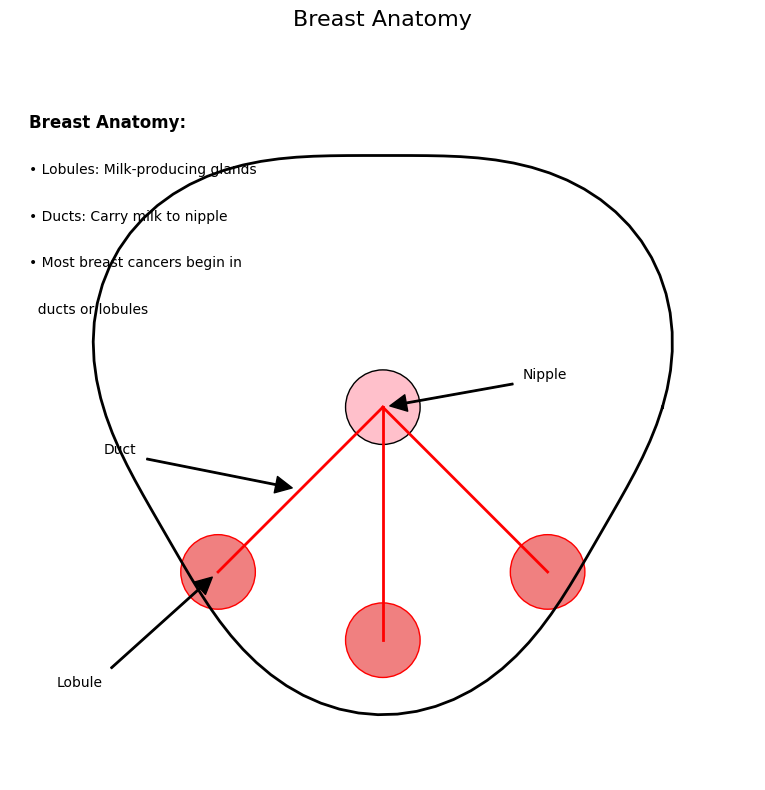

In [2]:
# Create a clearer breast anatomy diagram
fig, ax = plt.subplots(figsize=(10, 8))

# Define the breast outline
theta = np.linspace(0, 2*np.pi, 100)
r = 3 + 0.3*np.sin(3*theta)
x = r * np.cos(theta)
y = r * np.sin(theta)

# Plot breast outline
ax.plot(x, y, 'k-', linewidth=2)

# Add nipple
nipple = plt.Circle((0, 0), 0.4, color='pink', fill=True, ec='black')
ax.add_patch(nipple)

# Add ducts (clearer, with different colors)
duct_angles = [5*np.pi/4, 3*np.pi/2, 7*np.pi/4]
duct_endpoints = []
for i, angle in enumerate(duct_angles):
    length = 2.5
    end_x = length*np.cos(angle)
    end_y = length*np.sin(angle)
    duct_endpoints.append((end_x, end_y))
    # Draw the duct in red
    ax.plot([0, end_x], [0, end_y], 'r-', linewidth=2)

# Add lobules at the end of ducts
for end_x, end_y in duct_endpoints:
    lobule = plt.Circle((end_x, end_y), 0.4, color='lightcoral', fill=True, ec='red')
    ax.add_patch(lobule)

# Add better positioned and clearer labels
# Nipple label
ax.annotate('Nipple', xy=(0, 0), xytext=(1.5, 0.3), 
            arrowprops=dict(facecolor='black', shrink=0.05, width=1))

# Label one duct clearly
ax.annotate('Duct', xy=(duct_endpoints[0][0]/2, duct_endpoints[0][1]/2), 
            xytext=(-3, -0.5), 
            arrowprops=dict(facecolor='black', shrink=0.05, width=1))

# Label one lobule clearly
ax.annotate('Lobule', xy=(duct_endpoints[0]), xytext=(-3.5, -3), 
            arrowprops=dict(facecolor='black', shrink=0.05, width=1))

# Add explanatory text
ax.text(-3.8, 3, "Breast Anatomy:", fontsize=12, weight='bold')
ax.text(-3.8, 2.5, "• Lobules: Milk-producing glands", fontsize=10)
ax.text(-3.8, 2.0, "• Ducts: Carry milk to nipple", fontsize=10)
ax.text(-3.8, 1.5, "• Most breast cancers begin in", fontsize=10)
ax.text(-3.8, 1.0, "  ducts or lobules", fontsize=10)

# Set plot properties
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.set_title('Breast Anatomy', fontsize=16)
ax.axis('off')

plt.tight_layout()
plt.show()

## Normal vs. Cancer Cells

This visualization compares:
- **Normal breast cells**: Uniform in size and shape, organized in structure, with regular nuclei
- **Cancer cells**: Irregularly shaped and sized, with abnormal nuclei, and disorganized growth patterns

Cancer cells exhibit key hallmarks including uncontrolled division, irregular shapes, and variation in size. These cellular changes are what pathologists look for when examining breast tissue samples.

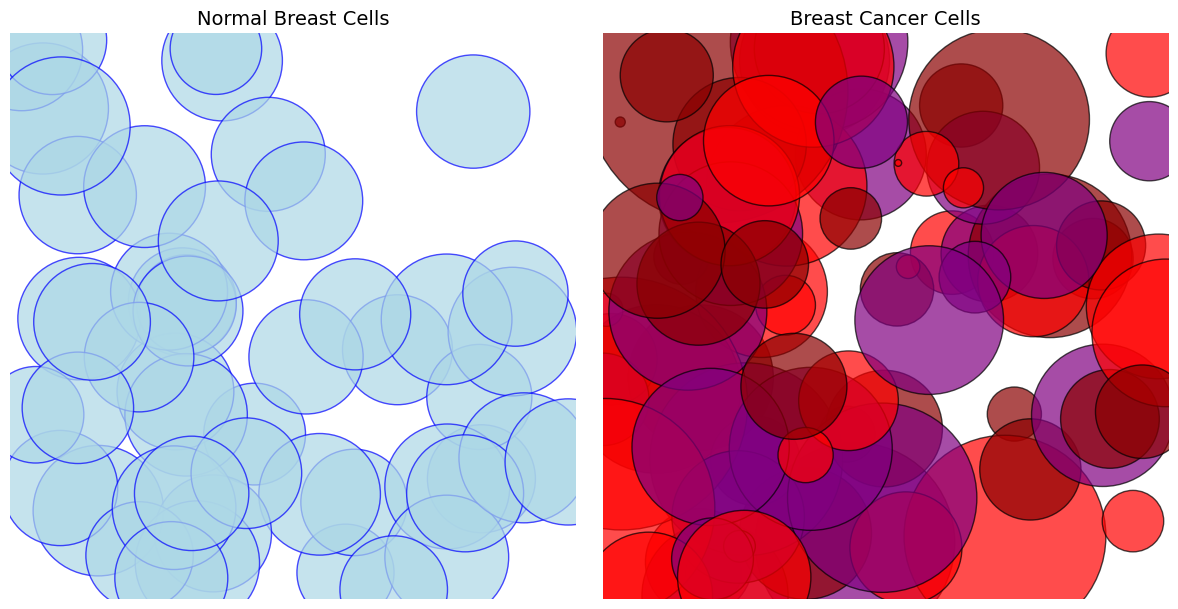

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Normal breast cells visualization
def normal_cells(ax):
    np.random.seed(42)
    for i in range(50):
        x, y = np.random.rand(2) * 10
        size = np.random.normal(1, 0.1)
        circle = plt.Circle((x, y), size, fc='lightblue', ec='blue', alpha=0.7)
        ax.add_patch(circle)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_title('Normal Breast Cells', fontsize=14)
    ax.set_aspect('equal')
    ax.axis('off')

# Cancer cells visualization
def cancer_cells(ax):
    np.random.seed(42)
    for i in range(80):  # More cells, crowded
        x, y = np.random.rand(2) * 10
        # Varied sizes for cancer cells
        size = np.random.normal(1, 0.5)
        # Varied colors to show abnormality
        color = np.random.choice(['red', 'darkred', 'purple'])
        circle = plt.Circle((x, y), size, fc=color, ec='black', alpha=0.7)
        ax.add_patch(circle)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_title('Breast Cancer Cells', fontsize=14)
    ax.set_aspect('equal')
    ax.axis('off')

normal_cells(ax1)
cancer_cells(ax2)
plt.tight_layout()
plt.show()

## Breast Cancer Types

This section illustrates four main types of breast cancer:

1. **Ductal Carcinoma In Situ (DCIS)**: 
   - Pre-invasive cancer contained within milk ducts
   - Non-invasive but can develop into invasive cancer if untreated

2. **Invasive Ductal Carcinoma (IDC)**:
   - Most common type (70-80% of breast cancers)
   - Begins in milk ducts then invades surrounding breast tissue
   - Can metastasize to other parts of the body

3. **Invasive Lobular Carcinoma (ILC)**:
   - Second most common type (10-15% of breast cancers) 
   - Begins in milk-producing lobules and can spread to other tissues
   - Often more difficult to detect on mammogram than IDC

4. **Inflammatory Breast Cancer**:
   - Rare but aggressive type
   - Characterized by redness, swelling, and skin changes
   - Often doesn't present as a distinct lump

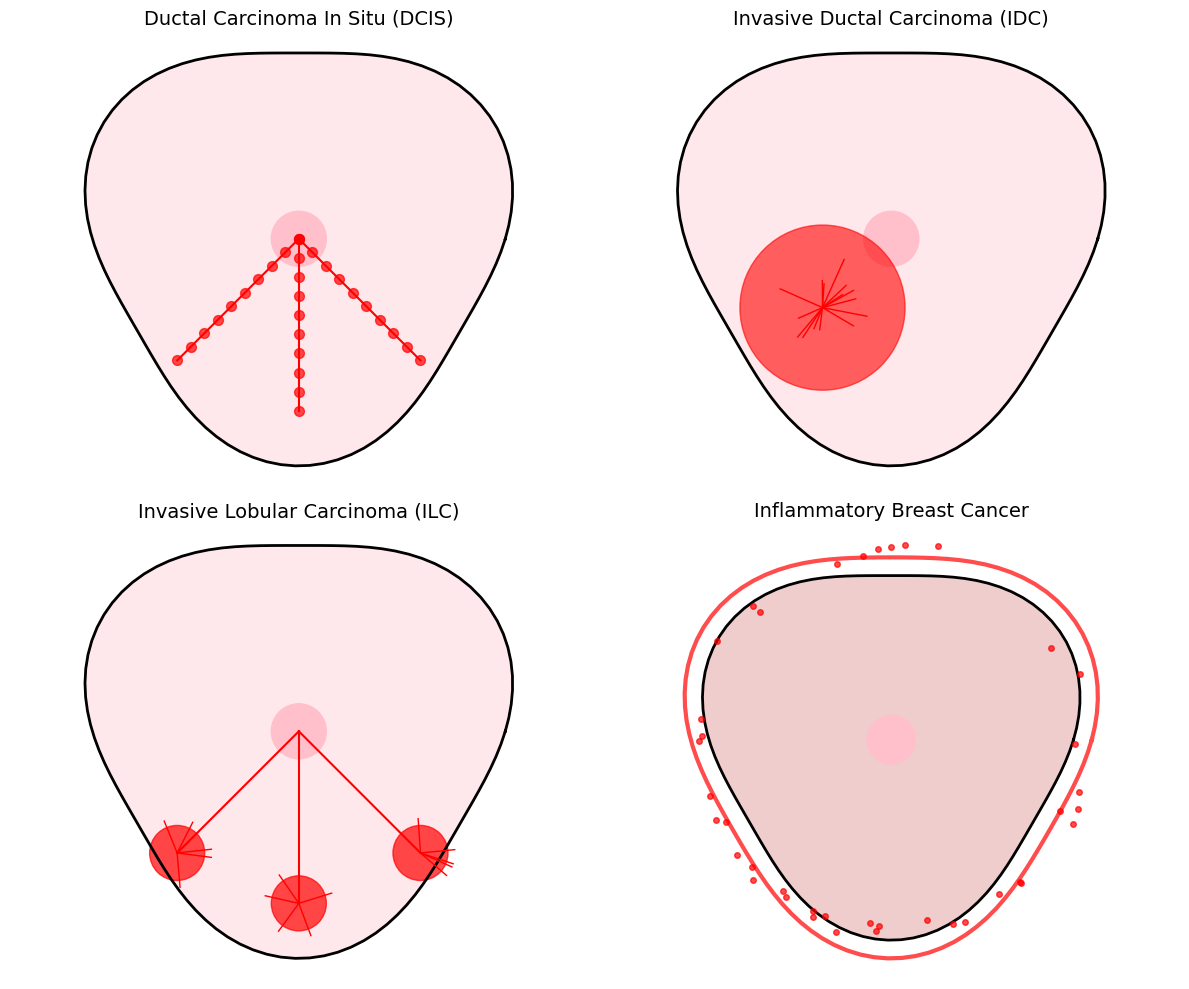

In [4]:
plt.figure(figsize=(12, 10))

# Main breast outline
def draw_breast(x_offset=0, color='lightpink'):
    theta = np.linspace(0, 2*np.pi, 100)
    r = 3 + 0.3*np.sin(3*theta)
    x = r * np.cos(theta) + x_offset
    y = r * np.sin(theta)
    plt.plot(x, y, 'k-', linewidth=2)
    plt.fill(x, y, color=color, alpha=0.3)
    # Add nipple
    circle = plt.Circle((x_offset, 0), 0.4, color='pink', fill=True)
    plt.gca().add_patch(circle)

# DCIS - Ductal Carcinoma In Situ
plt.subplot(221)
draw_breast()
# Draw ducts and show DCIS
for angle in [5*np.pi/4, 3*np.pi/2, 7*np.pi/4]:
    plt.plot([0, 2.5*np.cos(angle)], [0, 2.5*np.sin(angle)], 'r-', linewidth=1.5)
    # Show cancer cells in duct
    x = np.linspace(0, 2.5*np.cos(angle), 10)
    y = np.linspace(0, 2.5*np.sin(angle), 10)
    plt.scatter(x, y, c='red', s=50, alpha=0.7)
plt.title('Ductal Carcinoma In Situ (DCIS)', fontsize=14)
plt.axis('equal')
plt.axis('off')

# IDC - Invasive Ductal Carcinoma
plt.subplot(222)
draw_breast()
# Central tumor mass
mass = plt.Circle((-1, -1), 1.2, color='red', fill=True, alpha=0.6)
plt.gca().add_patch(mass)
# Invasion lines
for i in range(15):
    angle = np.random.uniform(0, 2*np.pi)
    length = np.random.uniform(0.3, 0.8)
    plt.plot([-1, -1+length*np.cos(angle)], 
             [-1, -1+length*np.sin(angle)], 'r-', linewidth=1)
plt.title('Invasive Ductal Carcinoma (IDC)', fontsize=14)
plt.axis('equal')
plt.axis('off')

# ILC - Invasive Lobular Carcinoma
plt.subplot(223)
draw_breast()
# Draw lobules
for angle in [5*np.pi/4, 3*np.pi/2, 7*np.pi/4]:
    end_x = 2.5*np.cos(angle) 
    end_y = 2.5*np.sin(angle)
    plt.plot([0, end_x], [0, end_y], 'r-', linewidth=1.5)
    circle = plt.Circle((end_x, end_y), 0.4, color='red', fill=True, alpha=0.7)
    plt.gca().add_patch(circle)
    # Show invasion from lobules
    for i in range(5):
        inv_angle = np.random.uniform(0, 2*np.pi)
        plt.plot([end_x, end_x+0.5*np.cos(inv_angle)], 
                 [end_y, end_y+0.5*np.sin(inv_angle)], 'r-', linewidth=1)
plt.title('Invasive Lobular Carcinoma (ILC)', fontsize=14)
plt.axis('equal')
plt.axis('off')

# Inflammatory Breast Cancer
plt.subplot(224)
draw_breast(color='indianred')
# Show skin thickening and redness
theta = np.linspace(0, 2*np.pi, 100)
r = 3.3 + 0.3*np.sin(3*theta)
x = r * np.cos(theta)
y = r * np.sin(theta)
plt.plot(x, y, 'r-', linewidth=3, alpha=0.7)
# Add inflammatory markers
for i in range(40):
    angle = np.random.uniform(0, 2*np.pi)
    r_pos = np.random.uniform(3, 3.3)
    plt.plot([r_pos*np.cos(angle)], [r_pos*np.sin(angle)], 'ro', alpha=0.7, markersize=4)
plt.title('Inflammatory Breast Cancer', fontsize=14)
plt.axis('equal')
plt.axis('off')

plt.tight_layout()
plt.show()

## Breast Cancer Receptors

This section illustrates how breast cancer cells may express different receptors:

1. **Estrogen Receptor (ER)**: 
   - When present (ER+), cancer cells need estrogen to grow
   - About 80% of breast cancers are ER+
   - Can be targeted with hormone therapy

2. **Progesterone Receptor (PR)**:
   - When present (PR+), cancer cells are stimulated by progesterone
   - Often correlates with ER status
   - Also targeted with hormone therapy

3. **HER2 Receptor**:
   - Human Epidermal Growth Factor Receptor 2
   - When overexpressed (HER2+), indicates a more aggressive cancer
   - Can be targeted with specific therapies like trastuzumab (Herceptin)

4. **Triple Negative Breast Cancer**:
   - Lacks all three receptors (ER-, PR-, HER2-)
   - More aggressive and fewer targeted treatment options
   - Represents about 10-15% of breast cancers

Receptor status is crucial for determining treatment approaches and predicting response to specific therapies.

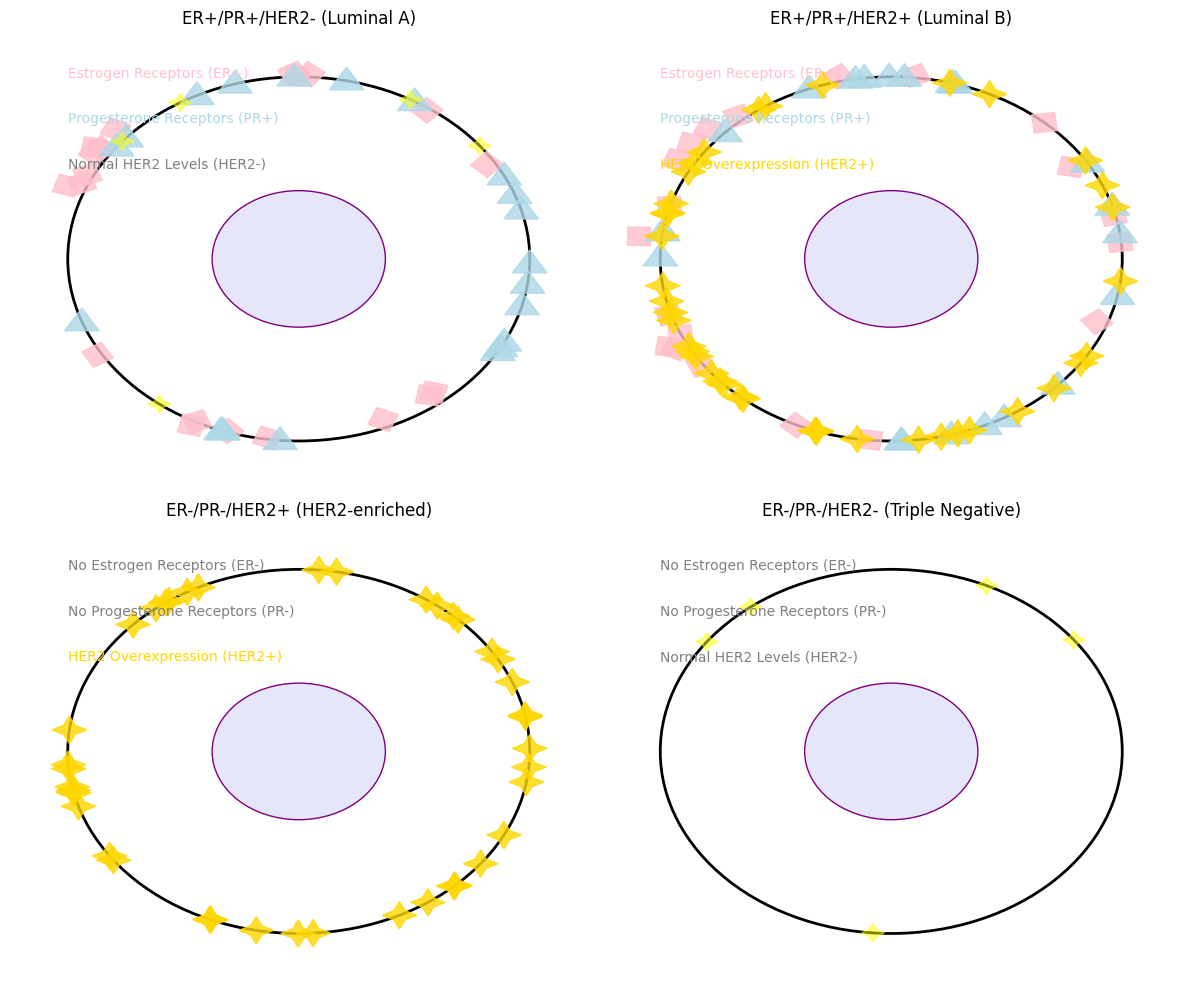

In [5]:
# Create a visualization of receptor types
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Helper function to draw a cell with receptors
def draw_cell_with_receptors(ax, title, 
                            has_er=False, 
                            has_pr=False, 
                            has_her2=False):
    # Draw cell membrane
    circle = plt.Circle((5, 5), 4, fill=False, ec='black', lw=2)
    ax.add_patch(circle)
    
    # Draw nucleus
    nucleus = plt.Circle((5, 5), 1.5, fill=True, fc='lavender', ec='purple')
    ax.add_patch(nucleus)
    
    # Draw ER receptors (if present)
    if has_er:
        for i in range(20):
            angle = np.random.uniform(0, 2*np.pi)
            r = 4  # At cell membrane
            x = 5 + r * np.cos(angle)
            y = 5 + r * np.sin(angle)
            rect = plt.Rectangle((x-0.2, y-0.2), 0.4, 0.4, 
                                 angle=np.random.uniform(0, 90),
                                 color='pink', alpha=0.8)
            ax.add_patch(rect)
        ax.text(1, 9, "Estrogen Receptors (ER+)", fontsize=10, color='pink')
    else:
        ax.text(1, 9, "No Estrogen Receptors (ER-)", fontsize=10, color='gray')
        
    # Draw PR receptors (if present)
    if has_pr:
        for i in range(20):
            angle = np.random.uniform(0, 2*np.pi)
            r = 4  # At cell membrane
            x = 5 + r * np.cos(angle)
            y = 5 + r * np.sin(angle)
            triangle = plt.Polygon([[x, y+0.3], [x-0.3, y-0.2], [x+0.3, y-0.2]], 
                                  color='lightblue', alpha=0.8)
            ax.add_patch(triangle)
        ax.text(1, 8, "Progesterone Receptors (PR+)", fontsize=10, color='lightblue')
    else:
        ax.text(1, 8, "No Progesterone Receptors (PR-)", fontsize=10, color='gray')
        
    # Draw HER2 receptors (if present)
    if has_her2:
        # Overexpression of HER2
        for i in range(40):  # More receptors for overexpression
            angle = np.random.uniform(0, 2*np.pi)
            r = 4  # At cell membrane
            x = 5 + r * np.cos(angle)
            y = 5 + r * np.sin(angle)
            star = plt.Polygon([[x, y+0.3], [x+0.1, y+0.1], [x+0.3, y], 
                              [x+0.1, y-0.1], [x, y-0.3], [x-0.1, y-0.1],
                              [x-0.3, y], [x-0.1, y+0.1]],
                             color='gold', alpha=0.8)
            ax.add_patch(star)
        ax.text(1, 7, "HER2 Overexpression (HER2+)", fontsize=10, color='gold')
    else:
        # Normal HER2 levels
        for i in range(5):  # Fewer receptors for normal expression
            angle = np.random.uniform(0, 2*np.pi)
            r = 4  # At cell membrane
            x = 5 + r * np.cos(angle)
            y = 5 + r * np.sin(angle)
            star = plt.Polygon([[x, y+0.2], [x+0.07, y+0.07], [x+0.2, y], 
                              [x+0.07, y-0.07], [x, y-0.2], [x-0.07, y-0.07],
                              [x-0.2, y], [x-0.07, y+0.07]],
                             color='yellow', alpha=0.5)
            ax.add_patch(star)
        ax.text(1, 7, "Normal HER2 Levels (HER2-)", fontsize=10, color='gray')
    
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# ER+/PR+/HER2-
draw_cell_with_receptors(axes[0, 0], "ER+/PR+/HER2- (Luminal A)", 
                        has_er=True, has_pr=True, has_her2=False)

# ER+/PR+/HER2+
draw_cell_with_receptors(axes[0, 1], "ER+/PR+/HER2+ (Luminal B)", 
                        has_er=True, has_pr=True, has_her2=True)

# ER-/PR-/HER2+
draw_cell_with_receptors(axes[1, 0], "ER-/PR-/HER2+ (HER2-enriched)", 
                        has_er=False, has_pr=False, has_her2=True)

# ER-/PR-/HER2- (Triple Negative)
draw_cell_with_receptors(axes[1, 1], "ER-/PR-/HER2- (Triple Negative)", 
                        has_er=False, has_pr=False, has_her2=False)

plt.tight_layout()
plt.show()

## Mammogram Visualization

This visualization compares:
- **Normal mammogram**: Shows regular breast tissue patterns with no suspicious areas
- **Mammogram with cancer**: Features a suspicious mass with irregular borders and higher density

Mammography is one of the primary screening tools for breast cancer. Radiologists look for:
- Masses with spiculated (spiky) or irregular borders
- Areas of increased density compared to surrounding tissue
- Architectural distortion of normal tissue patterns
- Microcalcifications (tiny calcium deposits)

Early detection through mammography is associated with better outcomes and more treatment options.

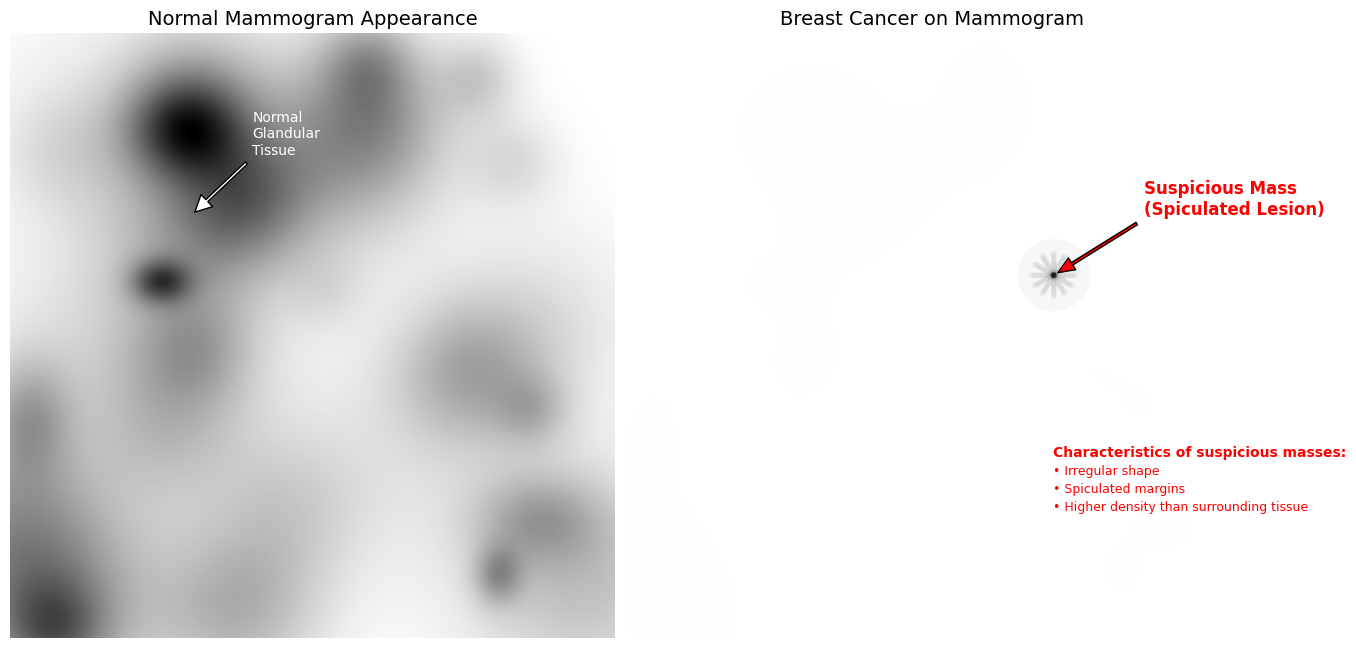

In [6]:
# Create a clearer synthetic mammogram comparison with a more OBVIOUS mass
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Normal mammogram-like visualization
def normal_mammo(ax):
    # Base tissue
    np.random.seed(42)
    x = np.linspace(0, 10, 1000)
    y = np.linspace(0, 10, 1000)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    
    # Add tissue patterns
    for i in range(25):
        x0, y0 = np.random.random(2) * 10
        amp = np.random.random() * 0.2 + 0.05
        sigma = np.random.random() * 1.5 + 0.5
        Z += amp * np.exp(-((X-x0)**2 + (Y-y0)**2) / sigma**2)
    
    # Add normal structures
    for i in range(5):
        x0, y0 = np.random.random(2) * 10
        amp = np.random.random() * 0.3 + 0.1
        sigma_x = np.random.random() * 0.8 + 0.3
        sigma_y = np.random.random() * 0.8 + 0.3
        Z += amp * np.exp(-((X-x0)**2/sigma_x**2 + (Y-y0)**2/sigma_y**2))
    
    # Display as grayscale mammogram
    ax.imshow(1 - Z, cmap='gray')
    
    # Add normal glandular tissue label
    ax.annotate('Normal\nGlandular\nTissue', 
                xy=(300, 300), 
                xytext=(400, 200),
                color='white',
                arrowprops=dict(facecolor='white', shrink=0.05, width=2))
    
    ax.set_title('Normal Mammogram Appearance', fontsize=14)
    ax.axis('off')

# Cancerous mammogram-like visualization WITH OBVIOUS MASS
def cancer_mammo(ax):
    # Use the same base as the normal (important for comparison)
    np.random.seed(42)
    x = np.linspace(0, 10, 1000)
    y = np.linspace(0, 10, 1000)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    
    # Add tissue patterns (same as normal)
    for i in range(25):
        x0, y0 = np.random.random(2) * 10
        amp = np.random.random() * 0.2 + 0.05
        sigma = np.random.random() * 1.5 + 0.5
        Z += amp * np.exp(-((X-x0)**2 + (Y-y0)**2) / sigma**2)
    
    # Add normal structures
    for i in range(5):
        x0, y0 = np.random.random(2) * 10
        amp = np.random.random() * 0.3 + 0.1
        sigma_x = np.random.random() * 0.8 + 0.3
        sigma_y = np.random.random() * 0.8 + 0.3
        Z += amp * np.exp(-((X-x0)**2/sigma_x**2 + (Y-y0)**2/sigma_y**2))
    
    # DIRECTLY ADD A VISIBLE MASS AT SPECIFIC PIXEL COORDINATES
    # Create a more distinct, high-density mass at center-right of image
    mass_center_y, mass_center_x = 400, 700  # Row, column format
    mass_radius = 60
    
    # Make an obvious circular mass
    y_coords, x_coords = np.ogrid[:1000, :1000]
    # Create the main mass (high density = dark in mammogram = low value in Z)
    mass_area = ((y_coords - mass_center_y)**2 + (x_coords - mass_center_x)**2 <= mass_radius**2)
    Z[mass_area] = Z[mass_area] + 2.0  # Dramatically increase density
    
    # Add spiculations (spikes) to the mass
    num_spikes = 12
    for i in range(num_spikes):
        angle = i * 2 * np.pi / num_spikes
        spike_length = mass_radius * 0.6
        end_y = int(mass_center_y + spike_length * np.sin(angle))
        end_x = int(mass_center_x + spike_length * np.cos(angle))
        
        # Create line of points for the spike
        rr, cc = np.array([]), np.array([])
        
        # Get line points
        line_points = np.linspace(0, 1, 20)
        for t in line_points:
            y = int(mass_center_y + t * (end_y - mass_center_y))
            x = int(mass_center_x + t * (end_x - mass_center_x))
            if 0 <= y < 1000 and 0 <= x < 1000:
                rr = np.append(rr, y)
                cc = np.append(cc, x)
        
        # Apply spike density
        for r, c in zip(rr.astype(int), cc.astype(int)):
            # Make a small circle at each point to thicken the spike
            y_grid, x_grid = np.ogrid[:1000, :1000]
            spike_point = ((y_grid - r)**2 + (x_grid - c)**2 <= 5**2)
            Z[spike_point] = Z[spike_point] + 1.5  # High density along spikes
    
    # Display as grayscale mammogram
    img = ax.imshow(1 - Z, cmap='gray')
    
    # Add a clear arrow pointing directly to the mass
    arrow = ax.annotate('Suspicious Mass\n(Spiculated Lesion)', 
                xy=(mass_center_x, mass_center_y),  # Point to mass center
                xytext=(mass_center_x + 150, mass_center_y - 100),  # Text position
                color='red',
                fontsize=12,
                weight='bold',
                arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=10))
    
    # Add characteristics callout
    ax.text(700, 700, "Characteristics of suspicious masses:", color='red', fontsize=10, weight='bold')
    ax.text(700, 730, "• Irregular shape", color='red', fontsize=9)
    ax.text(700, 760, "• Spiculated margins", color='red', fontsize=9)
    ax.text(700, 790, "• Higher density than surrounding tissue", color='red', fontsize=9)
    
    ax.set_title('Breast Cancer on Mammogram', fontsize=14)
    ax.axis('off')

normal_mammo(ax1)
cancer_mammo(ax2)
plt.tight_layout()
plt.show()

## Breast Cancer Staging

This visualization demonstrates the TNM staging system for breast cancer:

- **Stage 0**: Carcinoma in situ (DCIS or LCIS) - Cancer cells remain within ducts or lobules
  
- **Stage I**: Small tumor (≤2 cm) with no lymph node involvement
  
- **Stage II**: 
  - Tumor 2-5 cm and/or
  - Limited spread to nearby lymph nodes
  
- **Stage III**: 
  - Larger tumor or extension to chest wall/skin
  - More extensive lymph node involvement
  
- **Stage IV**: Metastatic breast cancer - spread to distant organs like bones, lungs, liver, or brain

Staging helps determine prognosis and guides treatment decisions. Earlier stages generally have better outcomes and may require less aggressive treatment.

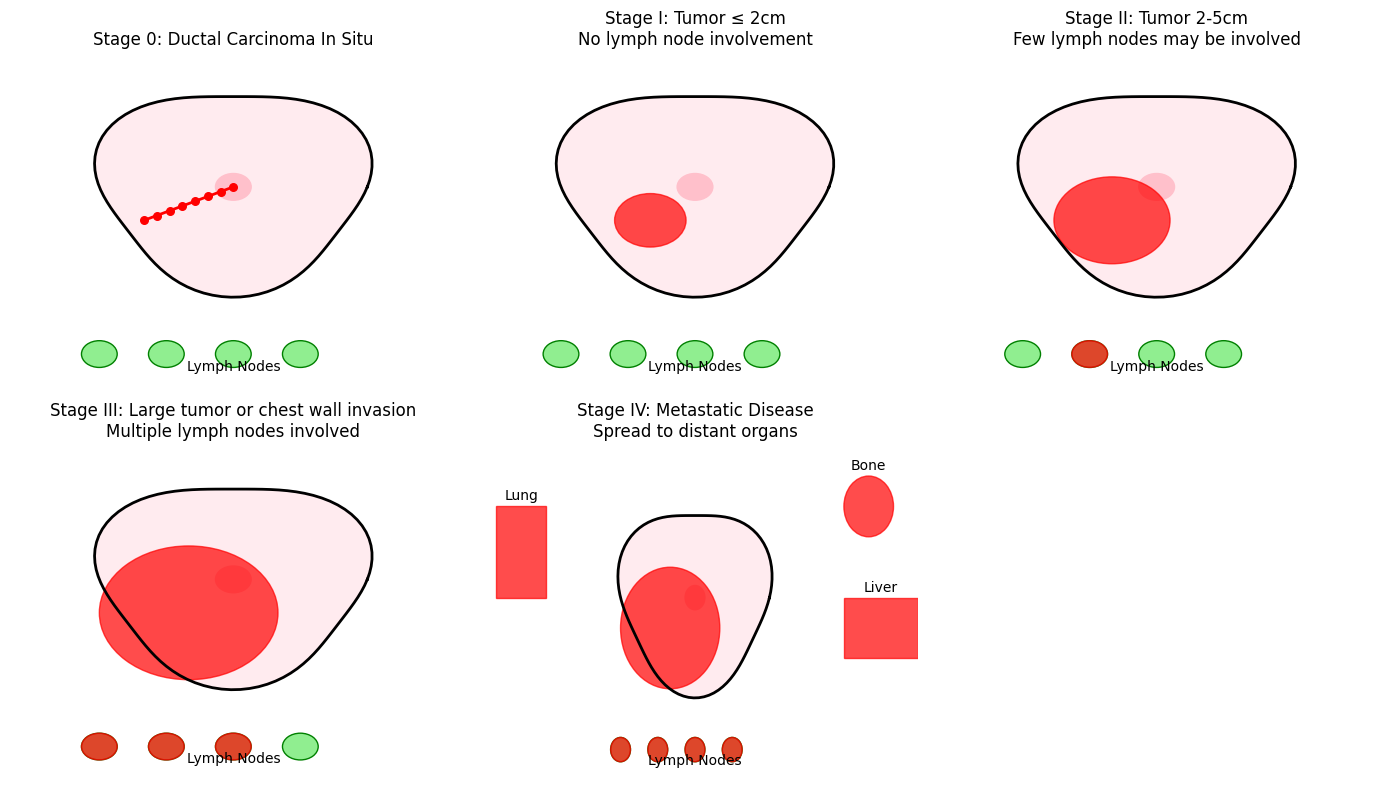

In [7]:
# Create visualization for cancer staging
plt.figure(figsize=(14, 8))

# Helper function to draw a basic breast
def draw_basic_breast(ax, x_offset=0):
    theta = np.linspace(0, 2*np.pi, 100)
    r = 3 + 0.3*np.sin(3*theta)
    x = r * np.cos(theta) + x_offset
    y = r * np.sin(theta)
    ax.plot(x, y, 'k-', linewidth=2)
    ax.fill(x, y, color='pink', alpha=0.3)
    # Add nipple
    circle = plt.Circle((x_offset, 0), 0.4, color='pink', fill=True)
    ax.add_patch(circle)
    # Draw simplified lymph nodes
    for pos in [(-3, -5), (-1.5, -5), (0, -5), (1.5, -5)]:
        circle = plt.Circle((pos[0] + x_offset, pos[1]), 0.4, color='lightgreen', 
                           fill=True, ec='green')
        ax.add_patch(circle)
    # Label lymph nodes
    ax.text(x_offset, -5.5, "Lymph Nodes", ha='center', fontsize=10)

# Stage 0: DCIS
plt.subplot(231)
ax = plt.gca()
draw_basic_breast(ax)
# Show DCIS in a duct
plt.plot([0, -2], [0, -1], 'r-', linewidth=2)
plt.scatter(np.linspace(0, -2, 8), np.linspace(0, -1, 8), c='red', s=30)
plt.title('Stage 0: Ductal Carcinoma In Situ', fontsize=12)
plt.xlim(-5, 5)
plt.ylim(-6, 4)
plt.axis('off')

# Stage I
plt.subplot(232)
ax = plt.gca()
draw_basic_breast(ax)
# Small primary tumor
tumor = plt.Circle((-1, -1), 0.8, color='red', fill=True, alpha=0.7)
ax.add_patch(tumor)
plt.title('Stage I: Tumor ≤ 2cm\nNo lymph node involvement', fontsize=12)
plt.xlim(-5, 5)
plt.ylim(-6, 4)
plt.axis('off')

# Stage II
plt.subplot(233)
ax = plt.gca()
draw_basic_breast(ax)
# Medium primary tumor
tumor = plt.Circle((-1, -1), 1.3, color='red', fill=True, alpha=0.7)
ax.add_patch(tumor)
# One affected lymph node
node = plt.Circle((-1.5, -5), 0.4, color='red', fill=True, alpha=0.7)
ax.add_patch(node)
plt.title('Stage II: Tumor 2-5cm\nFew lymph nodes may be involved', fontsize=12)
plt.xlim(-5, 5)
plt.ylim(-6, 4)
plt.axis('off')

# Stage III
plt.subplot(234)
ax = plt.gca()
draw_basic_breast(ax)
# Larger tumor
tumor = plt.Circle((-1, -1), 2, color='red', fill=True, alpha=0.7)
ax.add_patch(tumor)
# Multiple affected lymph nodes
for pos in [(-3, -5), (-1.5, -5), (0, -5)]:
    node = plt.Circle(pos, 0.4, color='red', fill=True, alpha=0.7)
    ax.add_patch(node)
plt.title('Stage III: Large tumor or chest wall invasion\nMultiple lymph nodes involved', fontsize=12)
plt.xlim(-5, 5)
plt.ylim(-6, 4)
plt.axis('off')

# Stage IV
plt.subplot(235)
ax = plt.gca()
draw_basic_breast(ax)
# Large primary tumor
tumor = plt.Circle((-1, -1), 2, color='red', fill=True, alpha=0.7)
ax.add_patch(tumor)
# All lymph nodes affected
for pos in [(-3, -5), (-1.5, -5), (0, -5), (1.5, -5)]:
    node = plt.Circle(pos, 0.4, color='red', fill=True, alpha=0.7)
    ax.add_patch(node)
    
# Add metastases to other organs
lung_met = plt.Rectangle((-8, 0), 2, 3, color='red', alpha=0.7)
ax.add_patch(lung_met)
ax.text(-7, 3.2, "Lung", ha='center')

liver_met = plt.Rectangle((6, -2), 3, 2, color='red', alpha=0.7)
ax.add_patch(liver_met)
ax.text(7.5, 0.2, "Liver", ha='center')

bone_met = plt.Circle((7, 3), 1, color='red', alpha=0.7)
ax.add_patch(bone_met)
ax.text(7, 4.2, "Bone", ha='center')

plt.title('Stage IV: Metastatic Disease\nSpread to distant organs', fontsize=12)
plt.xlim(-9, 9)
plt.ylim(-6, 5)
plt.axis('off')

plt.tight_layout()
plt.show()

## Treatment Options

This section outlines the major treatment approaches for breast cancer:

1. **Surgery**:
   - Lumpectomy: Removes tumor while preserving most breast tissue
   - Mastectomy: Removes the entire breast
   - Lymph node surgery: To check for cancer spread

2. **Radiation Therapy**:
   - Uses high-energy beams to kill remaining cancer cells
   - Often follows surgery, especially lumpectomy
   - May be external or internal (brachytherapy)

3. **Chemotherapy**:
   - Systemic treatment that targets rapidly dividing cells
   - May be given before surgery (neoadjuvant) or after (adjuvant)
   - Common for larger tumors or node-positive disease

4. **Hormone Therapy**:
   - For ER+ or PR+ cancers
   - Blocks hormone effects on cancer cells
   - Includes tamoxifen, aromatase inhibitors

5. **Targeted Therapy**:
   - Focuses on specific features of cancer cells
   - HER2-targeted drugs like trastuzumab for HER2+ cancers
   - CDK4/6 inhibitors, PARP inhibitors, etc.

6. **Immunotherapy**:
   - Enhances the body's immune response against cancer
   - Newer approach for certain breast cancers

Treatment is personalized based on cancer stage, receptor status, patient age, general health, and preferences.

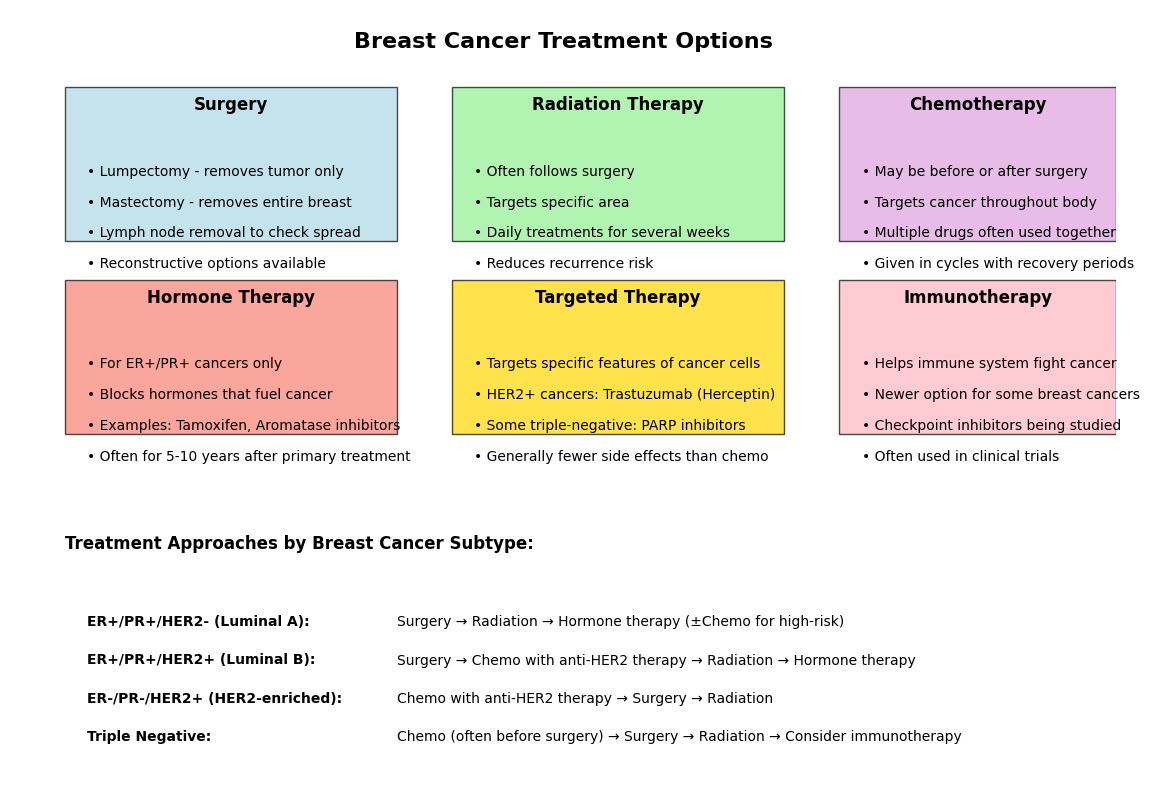

In [8]:
# Create a visualization of treatment options
fig, ax = plt.subplots(figsize=(12, 8))

# Set up base canvas
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, "Breast Cancer Treatment Options", fontsize=16, ha='center', weight='bold')

# Create treatment blocks
def add_treatment_block(x, y, width, height, title, details, color):
    # Main block
    rect = plt.Rectangle((x, y), width, height, facecolor=color, edgecolor='black', alpha=0.7)
    ax.add_patch(rect)
    # Title
    ax.text(x + width/2, y + height - 0.3, title, fontsize=12, ha='center', weight='bold')
    # Details
    detail_y = y + height - 0.7
    for detail in details:
        detail_y -= 0.4
        ax.text(x + 0.2, detail_y, "• " + detail, fontsize=10, va='center')

# Surgery
surgery_details = [
    "Lumpectomy - removes tumor only",
    "Mastectomy - removes entire breast",
    "Lymph node removal to check spread",
    "Reconstructive options available"
]
add_treatment_block(0.5, 7, 3, 2, "Surgery", surgery_details, 'lightblue')

# Radiation
radiation_details = [
    "Often follows surgery",
    "Targets specific area",
    "Daily treatments for several weeks",
    "Reduces recurrence risk"
]
add_treatment_block(4, 7, 3, 2, "Radiation Therapy", radiation_details, 'lightgreen')

# Chemotherapy
chemo_details = [
    "May be before or after surgery",
    "Targets cancer throughout body",
    "Multiple drugs often used together",
    "Given in cycles with recovery periods"
]
add_treatment_block(7.5, 7, 2.5, 2, "Chemotherapy", chemo_details, 'plum')

# Hormone Therapy
hormone_details = [
    "For ER+/PR+ cancers only",
    "Blocks hormones that fuel cancer",
    "Examples: Tamoxifen, Aromatase inhibitors",
    "Often for 5-10 years after primary treatment"
]
add_treatment_block(0.5, 4.5, 3, 2, "Hormone Therapy", hormone_details, 'salmon')

# Targeted Therapy
targeted_details = [
    "Targets specific features of cancer cells",
    "HER2+ cancers: Trastuzumab (Herceptin)",
    "Some triple-negative: PARP inhibitors",
    "Generally fewer side effects than chemo"
]
add_treatment_block(4, 4.5, 3, 2, "Targeted Therapy", targeted_details, 'gold')

# Immunotherapy
immuno_details = [
    "Helps immune system fight cancer",
    "Newer option for some breast cancers",
    "Checkpoint inhibitors being studied",
    "Often used in clinical trials"
]
add_treatment_block(7.5, 4.5, 2.5, 2, "Immunotherapy", immuno_details, 'lightpink')

# Add treatment by subtype notes at bottom
ax.text(0.5, 3, "Treatment Approaches by Breast Cancer Subtype:", fontsize=12, weight='bold')

subtypes = [
    ("ER+/PR+/HER2- (Luminal A)", "Surgery → Radiation → Hormone therapy (±Chemo for high-risk)"),
    ("ER+/PR+/HER2+ (Luminal B)", "Surgery → Chemo with anti-HER2 therapy → Radiation → Hormone therapy"),
    ("ER-/PR-/HER2+ (HER2-enriched)", "Chemo with anti-HER2 therapy → Surgery → Radiation"),
    ("Triple Negative", "Chemo (often before surgery) → Surgery → Radiation → Consider immunotherapy")
]

y_pos = 2.5
for subtype, treatment in subtypes:
    y_pos -= 0.5
    ax.text(0.7, y_pos, subtype + ":", fontsize=10, weight='bold')
    ax.text(3.5, y_pos, treatment, fontsize=10)

plt.tight_layout()
plt.show()

## Survival Rates and Outcomes

This visualization shows:
- **5-year survival rates by stage**: Demonstrating the dramatic difference in outcomes based on stage at diagnosis
- **Treatment response by receptor status**: Illustrating how different breast cancer subtypes respond to various treatment approaches

Key insights:
- Early-stage breast cancers have excellent survival rates (>90%)
- Advanced-stage cancers have more limited outcomes but improving with new therapies
- ER+/PR+ cancers generally respond well to hormone therapy
- HER2+ cancers benefit from targeted anti-HER2 therapies
- Triple-negative breast cancers remain challenging but are the focus of intensive research

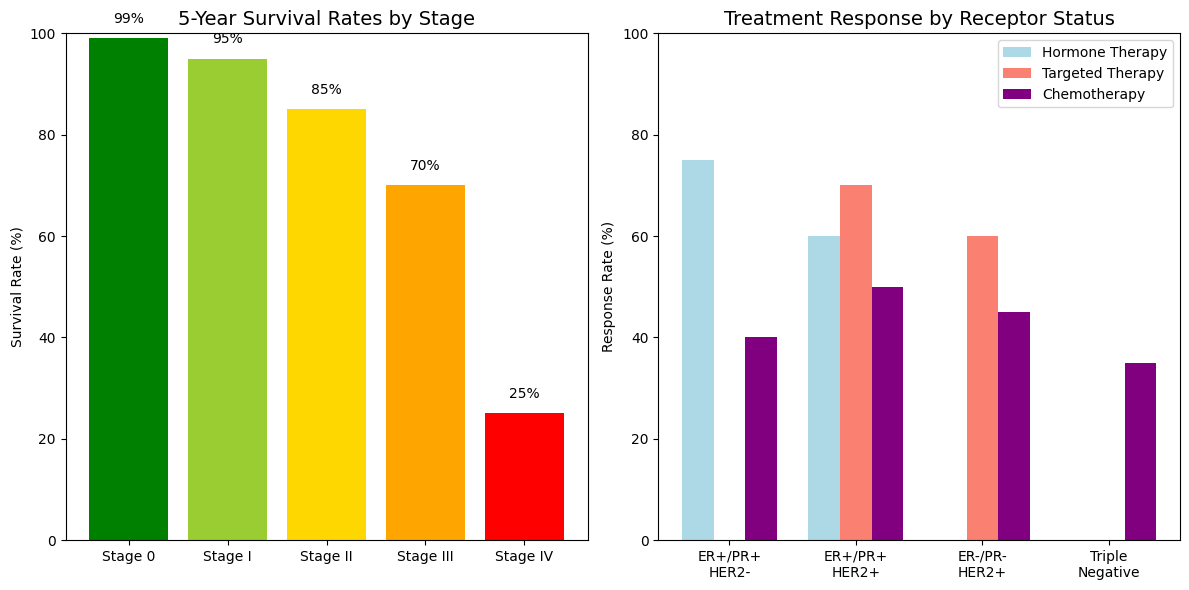

In [9]:
# Create survival rate and treatment outcome visualization
plt.figure(figsize=(12, 6))

# Survival rates by stage
plt.subplot(121)
stages = ['Stage 0', 'Stage I', 'Stage II', 'Stage III', 'Stage IV']
survival_rates = [99, 95, 85, 70, 25]  # 5-year survival rates (approximate)

colors = ['green', 'yellowgreen', 'gold', 'orange', 'red']
plt.bar(stages, survival_rates, color=colors)
plt.title('5-Year Survival Rates by Stage', fontsize=14)
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)

for i, v in enumerate(survival_rates):
    plt.text(i, v + 3, f"{v}%", ha='center')

# Treatment effectiveness by receptor status
plt.subplot(122)
receptor_types = ['ER+/PR+\nHER2-', 'ER+/PR+\nHER2+', 'ER-/PR-\nHER2+', 'Triple\nNegative']

# Simulated response rates to different treatments
hormone_therapy = [75, 60, 0, 0]
targeted_therapy = [0, 70, 60, 0]
chemo = [40, 50, 45, 35]

width = 0.25
x = np.arange(len(receptor_types))

plt.bar(x - width, hormone_therapy, width, label='Hormone Therapy', color='lightblue')
plt.bar(x, targeted_therapy, width, label='Targeted Therapy', color='salmon')
plt.bar(x + width, chemo, width, label='Chemotherapy', color='purple')

plt.title('Treatment Response by Receptor Status', fontsize=14)
plt.ylabel('Response Rate (%)')
plt.ylim(0, 100)
plt.xticks(x, receptor_types)
plt.legend()

plt.tight_layout()
plt.show()

## Patient Journey

The flowchart illustrates the typical patient journey from screening through treatment and follow-up:

1. **Screening/Detection**: Through mammography, clinical exam, or patient-detected symptoms
2. **Diagnostic Testing**: More detailed imaging and biopsy
3. **Diagnosis and Staging**: Determining cancer type, receptor status, and extent
4. **Treatment Planning**: Multidisciplinary approach involving surgeons, oncologists, radiation oncologists
5. **Treatments**: Surgery, radiation, chemotherapy, targeted therapies
6. **Follow-up Care**: Monitoring for recurrence, managing side effects, survivorship support

Every patient's journey is unique, with treatment decisions made collaboratively between patients and their healthcare team.

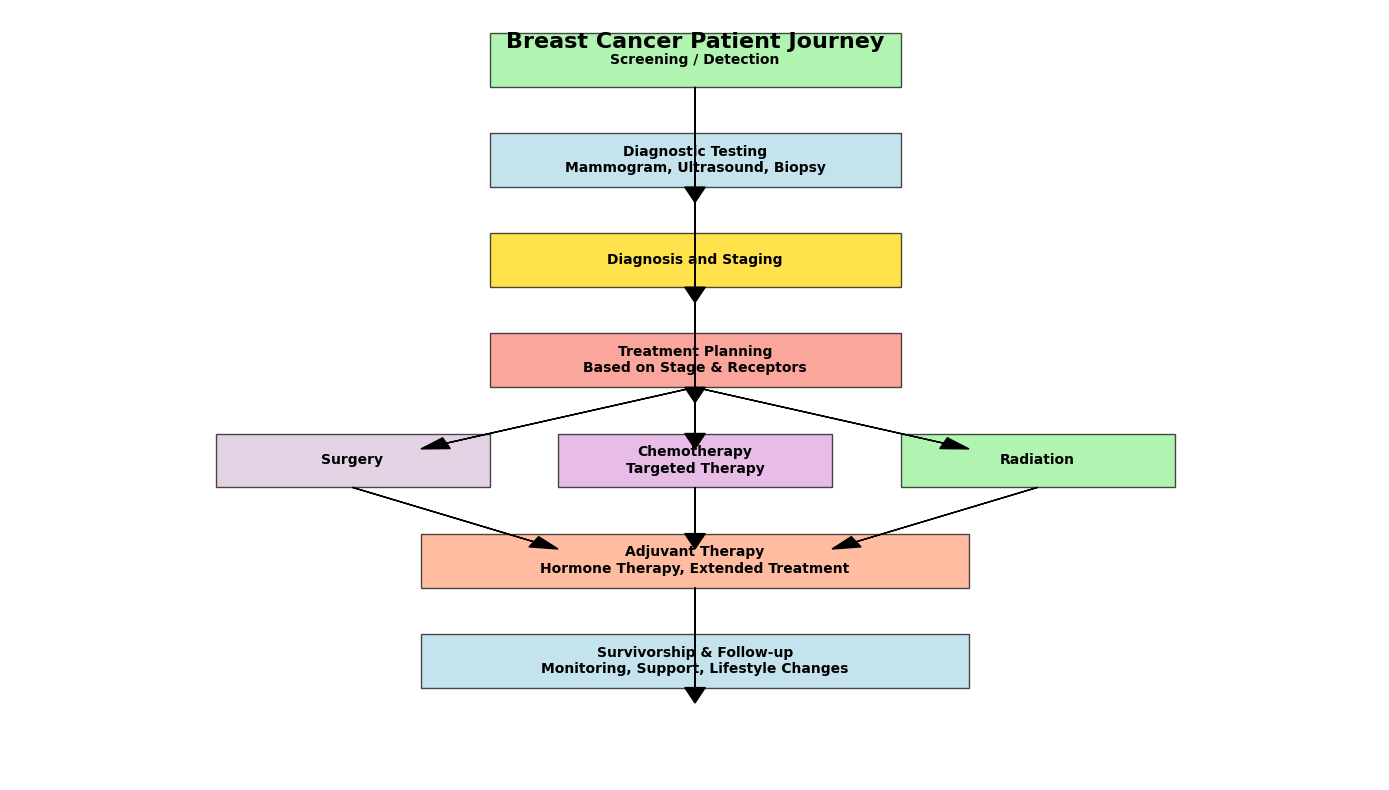

In [10]:
# Create a flowchart visualizing breast cancer journey
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, "Breast Cancer Patient Journey", fontsize=16, ha='center', weight='bold')

def add_box(x, y, width, height, text, color='skyblue'):
    box = plt.Rectangle((x, y), width, height, facecolor=color, edgecolor='black', alpha=0.7)
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center', fontweight='bold', fontsize=10)
    return x + width/2, y  # Return top-middle coordinates for arrow connections

def add_arrow(start, end):
    ax.arrow(start[0], start[1], 0, end[1]-start[1]-0.2, 
             head_width=0.15, head_length=0.2, fc='black', ec='black', length_includes_head=True)

# Screening/Detection
start = add_box(3.5, 9, 3, 0.7, "Screening / Detection", color='lightgreen')

# Diagnostic Tests
diag = add_box(3.5, 7.7, 3, 0.7, "Diagnostic Testing\nMammogram, Ultrasound, Biopsy", color='lightblue')
add_arrow(start, diag)

# Diagnosis/Staging
staging = add_box(3.5, 6.4, 3, 0.7, "Diagnosis and Staging", color='gold')
add_arrow(diag, staging)

# Treatment Planning
plan = add_box(3.5, 5.1, 3, 0.7, "Treatment Planning\nBased on Stage & Receptors", color='salmon')
add_arrow(staging, plan)

# Different Treatment options
surgery = add_box(1.5, 3.8, 2, 0.7, "Surgery", color='thistle')
chemo = add_box(4, 3.8, 2, 0.7, "Chemotherapy\nTargeted Therapy", color='plum')
radiation = add_box(6.5, 3.8, 2, 0.7, "Radiation", color='lightgreen')

# Add arrows from planning to treatments
ax.arrow(5, 5.1, -2, -0.8, head_width=0.15, head_length=0.2, fc='black', ec='black', length_includes_head=True)
ax.arrow(5, 5.1, 0, -0.8, head_width=0.15, head_length=0.2, fc='black', ec='black', length_includes_head=True)
ax.arrow(5, 5.1, 2, -0.8, head_width=0.15, head_length=0.2, fc='black', ec='black', length_includes_head=True)

# Add adjuvant therapy 
hormonal = add_box(3, 2.5, 4, 0.7, "Adjuvant Therapy\nHormone Therapy, Extended Treatment", color='lightsalmon')

# Add arrows from treatments to adjuvant
ax.arrow(2.5, 3.8, 1.5, -0.8, head_width=0.15, head_length=0.2, fc='black', ec='black', length_includes_head=True)
ax.arrow(5, 3.8, 0, -0.8, head_width=0.15, head_length=0.2, fc='black', ec='black', length_includes_head=True)
ax.arrow(7.5, 3.8, -1.5, -0.8, head_width=0.15, head_length=0.2, fc='black', ec='black', length_includes_head=True)

# Survivorship and follow-up
follow = add_box(3, 1.2, 4, 0.7, "Survivorship & Follow-up\nMonitoring, Support, Lifestyle Changes", color='lightblue')
add_arrow((5, 2.5), (5, 1.2))

plt.tight_layout()
plt.show()

## Conclusion

Breast cancer is a complex disease with multiple subtypes, requiring individualized treatment approaches. Early detection remains crucial for optimal outcomes. Advances in our understanding of breast cancer biology have led to more targeted therapies and improved survival rates.

If you or someone you know is concerned about breast cancer, consult with healthcare professionals for proper screening, diagnosis, and treatment options.

# Breast Cancer Screening 


## Breast Density: A Key Risk Factor for Breast Cancer

### What is Breast Density?

Breast density refers to the relative amounts of different tissues in the breast:
- **Dense tissue**: Glandular tissue and fibrous connective tissue (appears white on mammograms)
- **Non-dense tissue**: Fatty tissue (appears dark or transparent on mammograms)

Breast density can only be determined through imaging (mammography), not by how breasts feel or appear externally.

### Breast Density Categories (BI-RADS Classification)

The American College of Radiology classifies breast density into four categories:

#### Category A: Almost Entirely Fatty (<25% dense tissue)
- Mostly dark appearance on mammograms
- Excellent visibility of potential abnormalities
- Approximately 10% of women

#### Category B: Scattered Fibroglandular Densities (25-50% dense tissue)
- Some scattered areas of density on a predominantly dark background
- Good visualization for most abnormalities
- Approximately 40% of women

#### Category C: Heterogeneously Dense (50-75% dense tissue)
- More extensive areas of density throughout the breast
- May obscure small masses
- Approximately 40% of women

#### Category D: Extremely Dense (>75% dense tissue)
- Mostly white appearance on mammograms
- Significantly reduced sensitivity for detecting abnormalities
- Approximately 10% of women

### Why Breast Density Matters

Dense breasts present two important challenges:

1. **Masking Effect**: Dense tissue can hide cancers on mammograms, reducing the effectiveness of standard screening.

2. **Independent Risk Factor**: Women with extremely dense breasts have approximately 1.5-2 times higher risk of developing breast cancer compared to women with average breast density.

It's like you are trying to find a white bear on the ice.

### Recommendations for Women with Dense Breasts

If you have dense breasts (Categories C or D), discuss these options with your healthcare provider:

- **Supplemental Screening**: Breast ultrasound, MRI, or 3D mammography (tomosynthesis) may improve cancer detection
- **Risk Assessment**: Other risk factors should be evaluated alongside breast density
- **Regular Screening**: Consistent and timely breast cancer screening remains essential

Most U.S. states now require that women be notified if they have dense breasts on mammography to help guide informed decision-making about screening.

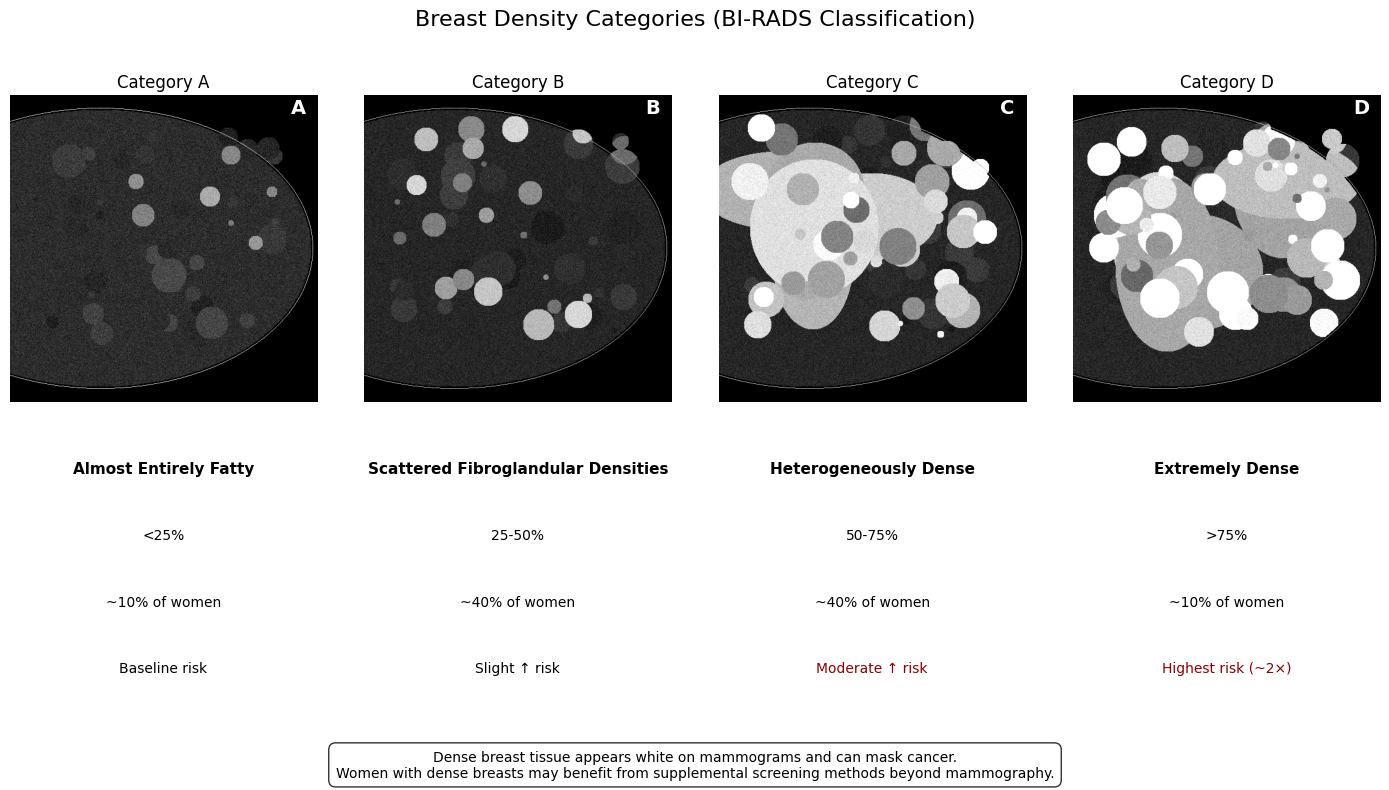

In [11]:
# Create synthetic breast density category images
import matplotlib.pyplot as plt
import numpy as np
from skimage import draw
from matplotlib.colors import LinearSegmentedColormap

# Create a figure with 4 breast density categories
fig, axes = plt.subplots(2, 4, figsize=(14, 8))

# Custom grayscale cmap for mammograms (black background)
mammogram_colors = [(0, 0, 0), (1, 1, 1)]  # Black to white
mammogram_cmap = LinearSegmentedColormap.from_list("mammogram", mammogram_colors)

# Function to create a synthetic mammogram with specified density
def create_synthetic_mammogram(density_percentage, random_seed=42):
    """
    Create a synthetic mammogram image with specified density percentage
    
    Parameters:
    density_percentage: 0-100, percentage of dense tissue
    random_seed: for reproducibility
    
    Returns:
    2D numpy array representing the synthetic mammogram
    """
    np.random.seed(random_seed)
    
    # Create a blank image (512x512)
    image = np.zeros((512, 512))
    
    # Create the basic breast shape (half-ellipse)
    rows, cols = draw.ellipse(256, 150, 230, 350, shape=image.shape)
    image[rows, cols] = 0.15  # Basic fatty tissue
    
    # Add some structure to fatty tissue
    for _ in range(40):
        x, y = np.random.randint(50, 450), np.random.randint(50, 400)
        r = np.random.randint(5, 30)
        rr, cc = draw.disk((y, x), r, shape=image.shape)
        image[rr, cc] = np.random.uniform(0.1, 0.25)
    
    # Add dense tissue based on density percentage
    num_dense_regions = int(70 * density_percentage / 100)  # Scale number of regions
    
    # For very dense tissue, add large connected regions
    if density_percentage > 50:
        # Add some large connected dense areas
        for _ in range(5):
            x, y = np.random.randint(100, 400), np.random.randint(100, 300)
            r_x = np.random.randint(50, 150)
            r_y = np.random.randint(50, 150)
            rr, cc = draw.ellipse(y, x, r_y, r_x, shape=image.shape)
            mask = np.zeros_like(image, dtype=bool)
            mask[rr, cc] = True
            mask = mask & (image > 0)  # Only within breast boundary
            image[mask] = np.random.uniform(0.5, 0.9)
    
    # Add scattered dense regions
    for _ in range(num_dense_regions):
        x, y = np.random.randint(50, 450), np.random.randint(50, 400)
        
        # Vary size based on density
        r = np.random.randint(5, 20 + int(density_percentage/5))
        
        # Create dense region
        rr, cc = draw.disk((y, x), r, shape=image.shape)
        mask = np.zeros_like(image, dtype=bool)
        mask[rr, cc] = True
        mask = mask & (image > 0)  # Only within breast boundary
        
        # Higher intensity for denser categories
        intensity = np.random.uniform(0.4, 0.5 + density_percentage/100)
        image[mask] = intensity
    
    # Add skin line
    rows, cols = draw.ellipse_perimeter(256, 150, 233, 353, shape=image.shape)
    valid_indices = (rows >= 0) & (rows < image.shape[0]) & (cols >= 0) & (cols < image.shape[1])
    image[rows[valid_indices], cols[valid_indices]] = 0.7
    
    # Add some texture
    texture = np.random.normal(0, 0.05, size=image.shape)
    image = np.clip(image + texture * (image > 0), 0, 1)
    
    return image

# Create synthetic mammograms with different densities
density_percentages = [10, 35, 65, 90]
category_labels = ['A', 'B', 'C', 'D']
density_names = [
    "Almost Entirely Fatty",
    "Scattered Fibroglandular Densities", 
    "Heterogeneously Dense",
    "Extremely Dense"
]
density_percentages_text = ["<25%", "25-50%", "50-75%", ">75%"]
prevalence = ["~10% of women", "~40% of women", "~40% of women", "~10% of women"]
risk_levels = ["Baseline risk", "Slight ↑ risk", "Moderate ↑ risk", "Highest risk (~2×)"]

for i, density in enumerate(density_percentages):
    # Generate and display the mammogram
    mammo = create_synthetic_mammogram(density, random_seed=42+i)
    axes[0, i].imshow(mammo, cmap=mammogram_cmap)
    axes[0, i].set_title(f"Category {category_labels[i]}", fontsize=12)
    axes[0, i].axis('off')
    
    # Add label at the top right of each image
    axes[0, i].text(480, 30, category_labels[i], color='white', 
                   fontsize=14, fontweight='bold', ha='center')
    
    # Create info panel for the bottom row
    axes[1, i].text(0.5, 0.8, density_names[i], ha='center', fontsize=11, fontweight='bold')
    axes[1, i].text(0.5, 0.6, density_percentages_text[i], ha='center', fontsize=10)
    axes[1, i].text(0.5, 0.4, prevalence[i], ha='center', fontsize=10)
    axes[1, i].text(0.5, 0.2, risk_levels[i], ha='center', fontsize=10, 
                  color='darkred' if i >= 2 else 'black')
    
    # Set background color based on risk level
    if i == 0:
        axes[1, i].set_facecolor('lightgreen')
    elif i == 1:
        axes[1, i].set_facecolor('khaki')
    elif i == 2:
        axes[1, i].set_facecolor('lightsalmon')
    else:
        axes[1, i].set_facecolor('lightcoral')
    
    axes[1, i].axis('off')
    
plt.suptitle("Breast Density Categories (BI-RADS Classification)", fontsize=16)

# Add explanatory note at the bottom
fig.text(0.5, 0.02, 
         "Dense breast tissue appears white on mammograms and can mask cancer.\n" +
         "Women with dense breasts may benefit from supplemental screening methods beyond mammography.",
         ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# Machine Learning Processing Paradigm (MLPP) for Breast Cancer Detection

The Machine Learning Processing Paradigm (MLPP) provides a structured approach to breast cancer detection, consisting of five key stages that transform raw medical data into actionable diagnostic insights:

## 1. Sensor
Medical imaging devices capture the initial biological data:
- **X-ray Digital Mammography**: The gold standard for breast cancer screening, providing high-resolution 2D images
- **Ultrasound**: Complementary to mammography, especially for dense breast tissue and differentiating cysts from solid masses
- **MRI**: Higher sensitivity for high-risk patients, detecting lesions mammography might miss
- **Digital Breast Tomosynthesis (3D Mammography)**: Creates multiple image slices, reducing tissue overlap issues

## 2. Image Acquisition
The process of capturing and digitizing the sensor output:
- **Sampling**: Converting continuous signals to discrete digital values at specific resolutions (spatial resolution typically 50-100 μm for mammography)
- **Quantization**: Assigning discrete intensity values (typically 12-16 bit depth for medical images)
- **Coding**: Representing image data in standard formats (DICOM for medical imaging)
- **Compression**: Reducing file size while preserving diagnostic information (lossless compression preferred for medical applications)

## 3. Data Conditioning
Preparing and enhancing the acquired images:
- **Noise Reduction**: Removing random variations and artifacts that can obscure important features
- **Contrast Enhancement**: Improving visibility of tissue structures and potential abnormalities
- **Histogram Equalization**: Distributing intensity values to improve overall contrast
- **Object Segmentation**: Isolating breast tissue from background and identifying regions of interest
- **Registration**: Aligning multiple images from different times or modalities

## 4. Feature Extraction
Identifying and measuring characteristics that differentiate normal from abnormal tissue:
- **Morphological Features**: Quantifying mass shape, size, margin characteristics, and boundary regularity
- **Texture Analysis**: Measuring tissue patterns using statistical methods like GLCM (Gray Level Co-occurrence Matrix)
- **Density Measurements**: Assessing tissue composition and density patterns
- **Calcification Analysis**: Detecting and characterizing microcalcifications that may indicate malignancy
- **Region-based Features**: Analyzing properties of segmented regions of interest

## 5. Modeling/Classification
Applying algorithms to make diagnostic predictions:
- **Machine Learning Models**: Support Vector Machines, Random Forests, and Neural Networks
- **Deep Learning Approaches**: Convolutional Neural Networks specialized for medical image analysis
- **Ensemble Methods**: Combining multiple models for improved accuracy
- **Binary Classification**: Distinguishing between malignant and benign findings
- **Risk Stratification**: Assessing likelihood of malignancy on a continuous scale

This MLPP workflow transforms raw sensor data into clinically relevant diagnostic information by progressively extracting and refining features that highlight abnormalities. Each stage builds upon the previous one, with the ultimate goal of providing accurate breast cancer detection while minimizing both false positives and false negatives.

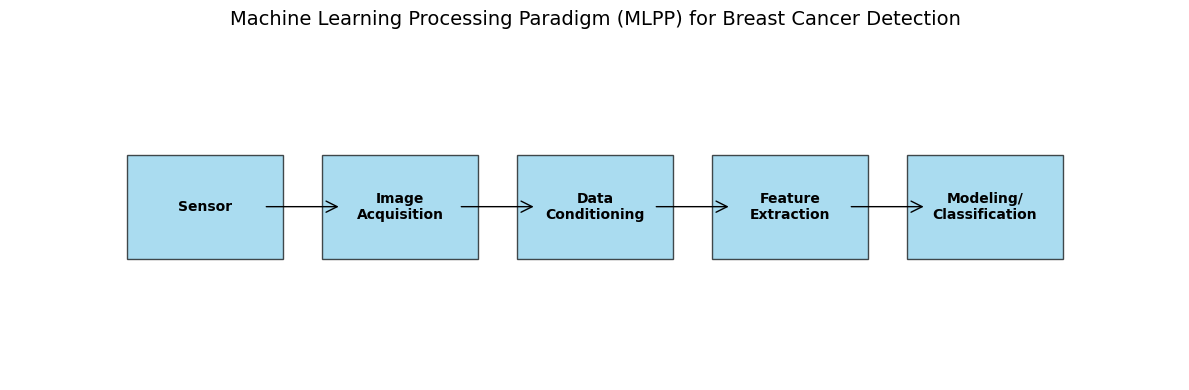

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 4))

# Define stages and positions
stages = ["Sensor", "Image\nAcquisition", "Data\nConditioning", 
          "Feature\nExtraction", "Modeling/\nClassification"]
positions = np.arange(len(stages))

# Create boxes for each stage
box_width = 0.8
box_height = 0.6
for i, stage in enumerate(stages):
    rect = plt.Rectangle((i-box_width/2, -box_height/2), box_width, box_height, 
                         facecolor='skyblue', edgecolor='black', alpha=0.7)
    ax.add_patch(rect)
    ax.text(i, 0, stage, ha='center', va='center', fontweight='bold')

# Add arrows connecting the stages
for i in range(len(stages)-1):
    arrow = FancyArrowPatch((i+box_width/2-0.1, 0), 
                           (i+1-box_width/2+0.1, 0),
                           arrowstyle='->', 
                           mutation_scale=20, 
                           color='black')
    ax.add_patch(arrow)

# Set plot limits and remove axes
ax.set_xlim(-1, len(stages))
ax.set_ylim(-1, 1)
ax.axis('off')

# Add title
plt.title('Machine Learning Processing Paradigm (MLPP) for Breast Cancer Detection', fontsize=14)
plt.tight_layout()
plt.savefig("MLPP_breast_cancer.png", dpi=300, bbox_inches="tight")
plt.show()

# Image Acquisition-Mammography Views 

## Cranio-Caudal (CC) View in Mammography

### What is the CC View?

The Cranio-Caudal (CC) view is one of the two standard views performed during mammography. This view provides a top-to-bottom image of the breast.

### Key Characteristics:

- **Direction**: X-ray beam travels from top (cranial) to bottom (caudal)
- **Positioning**: Breast is placed on the detector plate and compressed horizontally
- **Compression**: Applied from top to bottom
- **Labeled as**: "RCC" (right cranio-caudal) or "LCC" (left cranio-caudal)

### What the CC View Shows:

- **Visualization**: Excellent visualization of the central, medial, and lateral portions of the breast
- **Nipple**: Should be centered and in profile (seen at the edge of the breast)
- **Pectoral Muscle**: Sometimes visible at the posterior edge (back of the image)
- **Coverage**: Should include as much breast tissue as possible, especially medially

### Limitations:

- May not fully capture the axillary tail (outer portion of the breast near the armpit)
- Some posterior tissue near the chest wall might be missed

### Clinical Importance:

The CC view is essential for evaluating:
- Masses and calcifications in the central and medial breast
- Symmetry between left and right breasts
- Changes over time when compared with previous mammograms

When interpreted along with the Mediolateral Oblique (MLO) view, the CC view helps provide complete imaging of breast tissue for screening and diagnostic purposes.

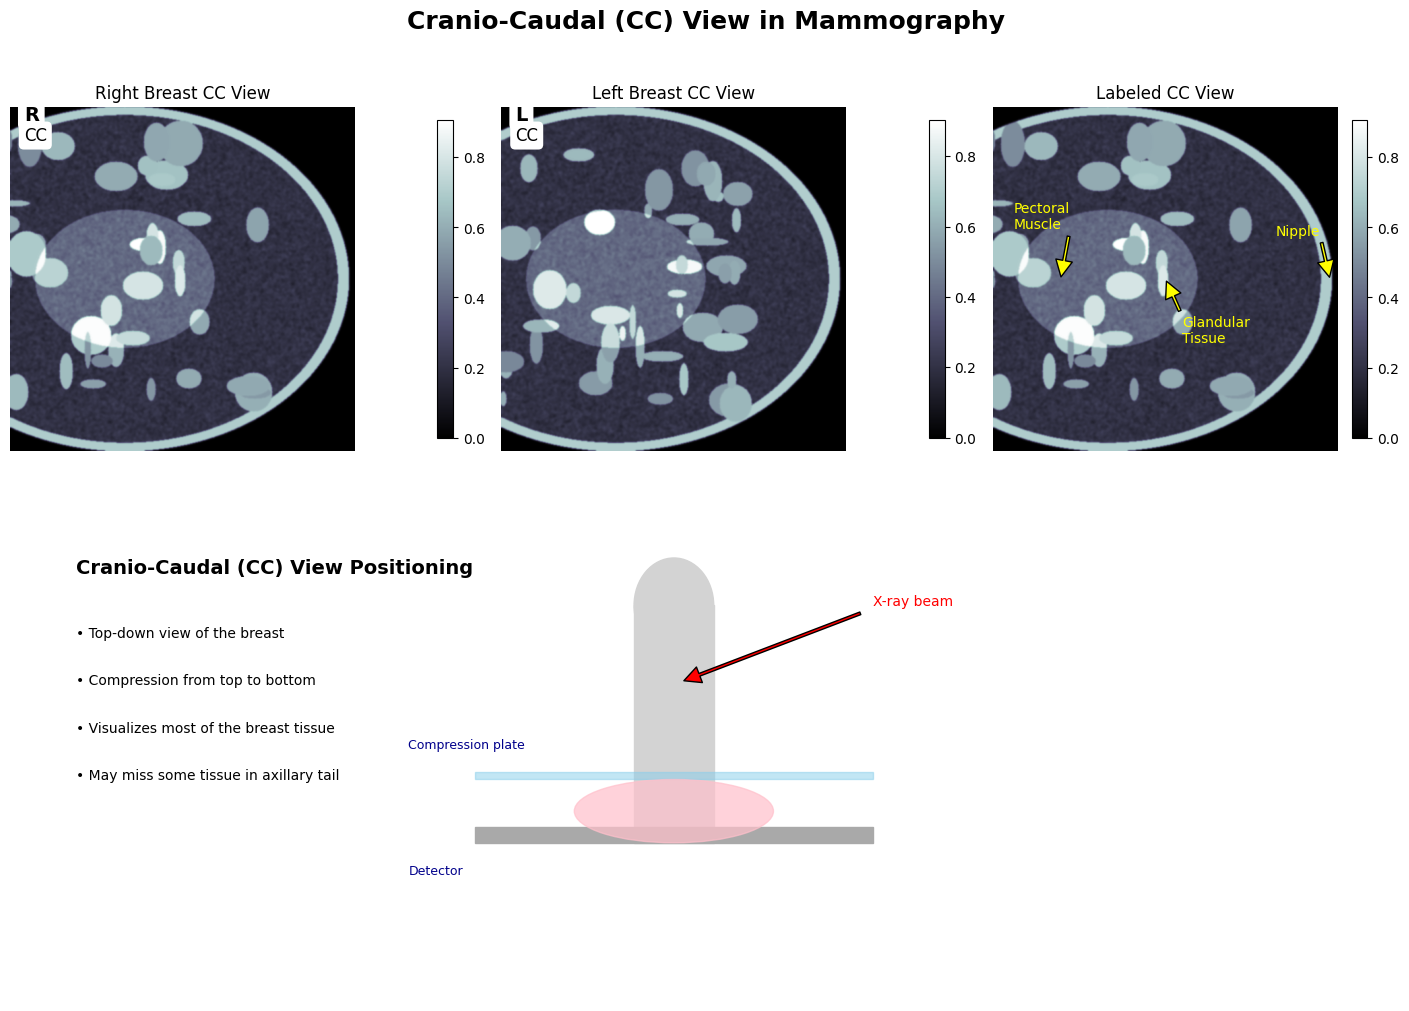

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.patches as patches
from matplotlib.patches import Ellipse  # FIX: use correct patch

# Create a synthetic CC view mammogram
def create_cc_view_mammogram(density_level=2, size=(512, 512), seed=42):
    np.random.seed(seed)
    image = np.zeros(size)
    
    height, width = size
    y, x = np.ogrid[:height, :width]
    center_x, center_y = width // 3, height // 2
    rad_x, rad_y = width * 0.65, height * 0.5
    
    distance = np.sqrt((x - center_x)**2 / rad_x**2 + (y - center_y)**2 / rad_y**2)
    breast_mask = distance <= 1.0
    
    image[breast_mask] = 0.2
    noise = np.random.normal(0, 0.1, size)
    image += noise * breast_mask
    image = gaussian_filter(image, sigma=1.5)
    
    edge_mask = (distance >= 0.95) & (distance <= 1.0)
    image[edge_mask] = 0.7
    
    if density_level >= 1:
        num_base_regions = 20 + density_level * 15
        for _ in range(num_base_regions):
            cx = np.random.randint(int(center_x - rad_x*0.8), int(center_x + rad_x*0.6))
            cy = np.random.randint(int(center_y - rad_y*0.8), int(center_y + rad_y*0.8))
            r_x = np.random.randint(5, 15 + 10*density_level)
            r_y = np.random.randint(5, 15 + 10*density_level)
            local_y, local_x = np.ogrid[:height, :width]
            distance = np.sqrt((local_x - cx)**2 / r_x**2 + (local_y - cy)**2 / r_y**2)
            region_mask = (distance <= 1.0) & breast_mask
            intensity = 0.3 + 0.15 * density_level + np.random.normal(0, 0.05)
            image[region_mask] = intensity
    
    r_central_x, r_central_y = rad_x * 0.4, rad_y * 0.4
    central_distance = np.sqrt((x - center_x)**2 / r_central_x**2 + (y - center_y)**2 / r_central_y**2)
    central_mask = (central_distance <= 1.0) & breast_mask
    image[central_mask] += 0.2
    
    image = np.clip(gaussian_filter(image, sigma=1.0), 0, 1)
    return image

# Create the figure
fig = plt.figure(figsize=(14, 10), constrained_layout=True)

# Create axes
ax1 = plt.subplot2grid((2, 3), (0, 0))
ax2 = plt.subplot2grid((2, 3), (0, 1))
ax3 = plt.subplot2grid((2, 3), (0, 2))
ax_diagram = plt.subplot2grid((2, 3), (1, 0), colspan=3)

# Create synthetic CC views
right_cc = create_cc_view_mammogram(density_level=2, seed=42)
left_cc = create_cc_view_mammogram(density_level=2, seed=43)

# Display right CC view
im1 = ax1.imshow(right_cc, cmap='bone')
ax1.set_title('Right Breast CC View', fontsize=12)
ax1.text(20, 20, 'R', color='black', fontsize=14, fontweight='bold',
         bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))
ax1.text(20, 50, 'CC', color='black', fontsize=12,
         bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))
ax1.axis('off')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Display left CC view
im2 = ax2.imshow(left_cc, cmap='bone')
ax2.set_title('Left Breast CC View', fontsize=12)
ax2.text(20, 20, 'L', color='black', fontsize=14, fontweight='bold',
         bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))
ax2.text(20, 50, 'CC', color='black', fontsize=12,
         bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))
ax2.axis('off')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# Labeled CC View
im3 = ax3.imshow(right_cc, cmap='bone')
ax3.set_title('Labeled CC View', fontsize=12)
ax3.axis('off')
fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

# Annotations
ax3.annotate('Nipple', xy=(500, 256), xytext=(420, 190),
             arrowprops=dict(facecolor='yellow', shrink=0.05, width=2),
             fontsize=10, color='yellow')

ax3.annotate('Pectoral\nMuscle', xy=(100, 256), xytext=(30, 180),
             arrowprops=dict(facecolor='yellow', shrink=0.05, width=2),
             fontsize=10, color='yellow')

ax3.annotate('Glandular\nTissue', xy=(256, 256), xytext=(280, 350),
             arrowprops=dict(facecolor='yellow', shrink=0.05, width=2),
             fontsize=10, color='yellow')

# CC positioning diagram
ax_diagram.set_xlim(0, 10)
ax_diagram.set_ylim(0, 3)

# Patient
head = plt.Circle((5, 2.5), 0.3, fill=True, color='lightgray')
ax_diagram.add_patch(head)

body = plt.Rectangle((4.7, 1), 0.6, 1.5, fill=True, color='lightgray')
ax_diagram.add_patch(body)

# Machine
detector_plate = plt.Rectangle((3.5, 1), 3, 0.1, fill=True, color='darkgray')
compression_plate = plt.Rectangle((3.5, 1.4), 3, 0.05, fill=True, color='skyblue', alpha=0.5)
ax_diagram.add_patch(detector_plate)
ax_diagram.add_patch(compression_plate)

# Breast
breast = Ellipse((5, 1.2), 1.5, 0.4, fill=True, color='pink', alpha=0.7)
ax_diagram.add_patch(breast)

# X-ray beam
ax_diagram.annotate('X-ray beam', xy=(5, 2), xytext=(6.5, 2.5),
                    arrowprops=dict(facecolor='red', shrink=0.05, width=2),
                    color='red', fontsize=10)

# Text labels
ax_diagram.text(0.5, 2.7, 'Cranio-Caudal (CC) View Positioning', fontsize=14, fontweight='bold')
ax_diagram.text(0.5, 2.3, '• Top-down view of the breast', fontsize=10)
ax_diagram.text(0.5, 2.0, '• Compression from top to bottom', fontsize=10)
ax_diagram.text(0.5, 1.7, '• Visualizes most of the breast tissue', fontsize=10)
ax_diagram.text(0.5, 1.4, '• May miss some tissue in axillary tail', fontsize=10)

ax_diagram.text(3, 0.8, 'Detector', color='darkblue', fontsize=9)
ax_diagram.text(3, 1.6, 'Compression plate', color='darkblue', fontsize=9)
ax_diagram.axis('off')

# Global title
plt.suptitle('Cranio-Caudal (CC) View in Mammography', fontsize=18, fontweight='bold')
plt.show()


## Medio-Lateral Oblique (MLO) Mammogram View

### Overview
The Medio-Lateral Oblique (MLO) view is one of the standard projections in mammography, providing a comprehensive visualization of breast tissue. This view captures the breast from an angled perspective.

### Anatomical Structures Visible in MLO Views

- **Pectoral Muscle**: Appears as a dense triangular region in the upper corner of the image
- **Breast Tissue**: Shows the majority of breast parenchyma, including:
  - Fibroglandular tissue (appears as white/bright regions)
  - Fatty tissue (appears as darker/more translucent areas)
- **Cooper's Ligaments**: Thin, linear structures visible throughout the breast
- **Ducts**: Branching structures that extend from the chest wall toward the nipple
- **Inframammary Fold**: The lower curved boundary where the breast attaches to the chest wall
- **Skin Line**: Thin bright outline visible around the breast perimeter
- **Nipple**: Should be in profile at the anterior margin of the breast

### Technical Aspects

MLO views are obtained with the X-ray beam angled 45° from horizontal, with compression applied obliquely. This positioning allows visualization of tissue that might be obscured in other views, particularly the upper outer quadrant where many breast cancers occur.

### Clinical Importance

- Considered the most comprehensive single mammographic view
- Offers better visualization of the axillary tail of the breast
- Shows the greatest amount of breast tissue in a single image
- When paired with the Cranio-Caudal (CC) view, provides complementary information for complete breast evaluation

The bilateral comparison of MLO views (left and right) helps radiologists identify asymmetries that may indicate pathology.

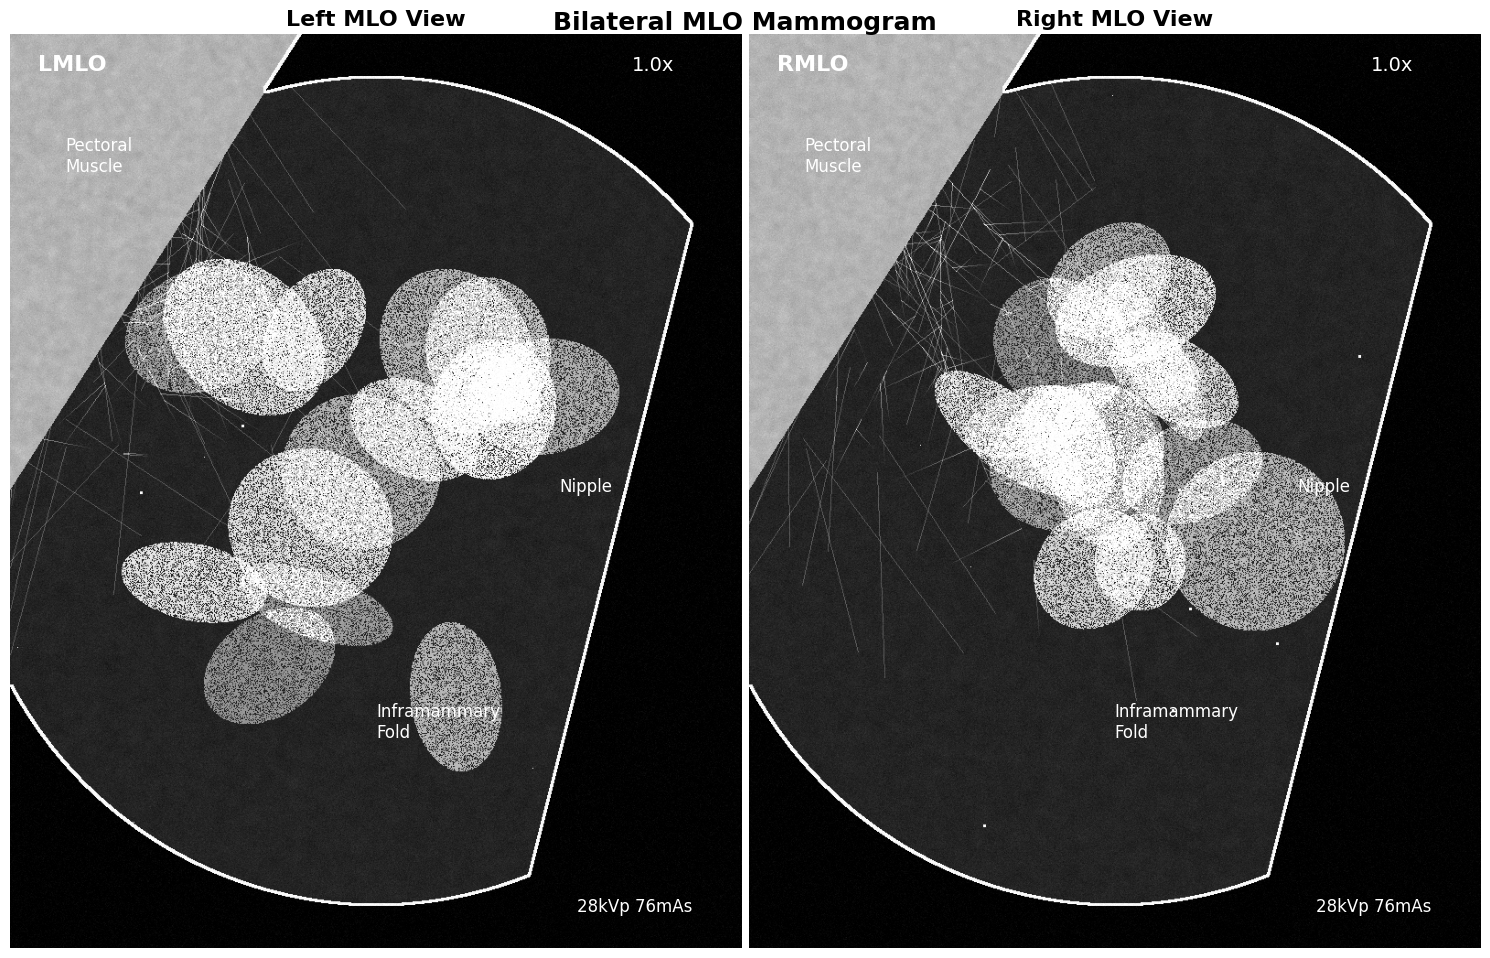

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.gridspec as gridspec
from skimage.draw import line, disk, ellipse
from matplotlib.colors import LinearSegmentedColormap

def create_realistic_mlo_mammogram(width=800, height=1000, seed=None):
    """Create a realistic synthetic MLO mammogram."""
    if seed is not None:
        np.random.seed(seed)
    
    # Create empty image
    image = np.zeros((height, width))
    
    # Create breast outline
    breast_mask = np.zeros((height, width), dtype=bool)
    pectoral_mask = np.zeros((height, width), dtype=bool)
    
    # Create pectoral muscle (triangle in upper corner)
    pectoral_height = height // 2
    for i in range(pectoral_height):
        pectoral_width = int(width * 0.4 * (1 - i / pectoral_height))
        pectoral_mask[i, :pectoral_width] = True
    
    # Create breast shape
    center_x, center_y = height // 2, width // 2
    for i in range(height):
        for j in range(width):
            # Create diagonal boundary for breast tissue
            if j < width - 1 - i/4:  # Angle of breast edge
                dist = np.sqrt((i - center_x)**2 + (j - center_y)**2)
                if dist < height // 2.2:  # Size of breast
                    breast_mask[i, j] = True
    
    # Combine masks
    combined_mask = breast_mask | pectoral_mask
    
    # Create base tissue texture - more random and detailed
    texture = np.random.normal(0.2, 0.05, (height, width))
    texture = gaussian_filter(texture, sigma=4)
    
    # Add tissue structures - Cooper's ligaments
    for _ in range(40):
        x1, y1 = np.random.randint(0, height//2), np.random.randint(0, width//2)
        length = np.random.randint(100, 300)
        angle = np.random.uniform(-np.pi/3, np.pi/3)
        x2 = int(x1 + length * np.cos(angle))
        y2 = int(y1 + length * np.sin(angle))
        
        rr, cc = line(x1, y1, min(height-1, max(0, x2)), min(width-1, max(0, y2)))
        valid_pts = (rr < height) & (cc < width) & (rr >= 0) & (cc >= 0) & combined_mask[rr, cc]
        if np.any(valid_pts):
            texture[rr[valid_pts], cc[valid_pts]] += 0.15
    
    # Add fibroglandular densities - more varied and realistic
    for _ in range(15):
        cx = np.random.randint(height//4, 3*height//4)
        cy = np.random.randint(width//4, 3*width//4)
        
        # Create irregular shape
        radius_x = np.random.randint(30, 100)
        radius_y = np.random.randint(30, 100)
        rotation = np.random.uniform(0, np.pi)
        
        # Create elliptical region
        rr, cc = ellipse(cx, cy, radius_x, radius_y, rotation=rotation, shape=(height, width))
        valid_pts = (combined_mask[rr, cc]) & (np.random.rand(len(rr)) > 0.3)  # Make it irregular
        
        if np.any(valid_pts):
            density = np.random.uniform(0.3, 0.6)
            texture[rr[valid_pts], cc[valid_pts]] += density
    
    # Add ducts and blood vessels - more branching structures
    for _ in range(20):
        # Start from chest wall
        start_x = np.random.randint(0, height//4)
        start_y = np.random.randint(0, width//3)
        
        # Create main branch
        length = np.random.randint(100, 400)
        angle = np.random.uniform(-np.pi/6, np.pi/3)
        end_x = int(start_x + length * np.cos(angle))
        end_y = int(start_y + length * np.sin(angle))
        
        rr, cc = line(start_x, start_y, min(height-1, max(0, end_x)), min(width-1, max(0, end_y)))
        valid_pts = (rr < height) & (cc < width) & (rr >= 0) & (cc >= 0) & combined_mask[rr, cc]
        
        if np.any(valid_pts):
            # Make vessels appear with gradient (thicker near wall, thinner at ends)
            intensity = 0.4 * (1 - np.arange(len(rr[valid_pts])) / len(rr[valid_pts]))
            texture[rr[valid_pts], cc[valid_pts]] += intensity
            
            # Add branches
            branch_points = np.random.choice(len(rr[valid_pts]), min(8, len(rr[valid_pts])//5), replace=False)
            for i in branch_points:
                if i < len(rr[valid_pts]):
                    branch_length = np.random.randint(20, 100)
                    branch_angle = angle + np.random.uniform(-np.pi/2, np.pi/2)
                    branch_x = int(rr[valid_pts][i] + branch_length * np.cos(branch_angle))
                    branch_y = int(cc[valid_pts][i] + branch_length * np.sin(branch_angle))
                    
                    brr, bcc = line(rr[valid_pts][i], cc[valid_pts][i], 
                                    min(height-1, max(0, branch_x)), 
                                    min(width-1, max(0, branch_y)))
                    
                    b_valid = (brr < height) & (bcc < width) & (brr >= 0) & (bcc >= 0) & combined_mask[brr, bcc]
                    if np.any(b_valid):
                        # Branches get thinner
                        b_intensity = 0.3 * (1 - np.arange(len(brr[b_valid])) / len(brr[b_valid]))
                        texture[brr[b_valid], bcc[b_valid]] += b_intensity
    
    # Add small calcifications (tiny bright spots)
    for _ in range(np.random.randint(10, 25)):
        cx, cy = np.random.randint(0, height), np.random.randint(0, width)
        if combined_mask[cx, cy]:
            radius = np.random.randint(1, 3)
            rr, cc = disk((cx, cy), radius)
            valid_pts = (rr < height) & (cc < width) & (rr >= 0) & (cc >= 0) & combined_mask[rr, cc]
            if np.any(valid_pts):
                texture[rr[valid_pts], cc[valid_pts]] += 0.7
    
    # Apply texture only inside the masks
    image[breast_mask] = texture[breast_mask]
    
    # Pectoral muscle appears denser
    pectoral_texture = np.random.normal(0.6, 0.1, (height, width))
    pectoral_texture = gaussian_filter(pectoral_texture, sigma=3)
    image[pectoral_mask] = pectoral_texture[pectoral_mask]
    
    # Add skin line
    skin = np.zeros_like(combined_mask, dtype=bool)
    skin_width = 3
    for i in range(height):
        for j in range(width):
            if combined_mask[i, j]:
                # Check if any neighboring pixel is background
                neighbors_background = False
                for di in range(-skin_width, skin_width+1):
                    for dj in range(-skin_width, skin_width+1):
                        ni, nj = i + di, j + dj
                        if (0 <= ni < height and 0 <= nj < width and 
                            not combined_mask[ni, nj]):
                            neighbors_background = True
                            break
                    if neighbors_background:
                        break
                if neighbors_background:
                    skin[i, j] = True
    
    # Make skin appear brighter
    image[skin] = 0.8
    
    # Enhance contrast
    image = np.clip((image - 0.1) * 1.4, 0, 1)
    
    # Add noise
    noise = np.random.normal(0, 0.02, (height, width))
    image = np.clip(image + noise, 0, 1)
    
    return image

def display_mlo_mammograms():
    # Create figure with just MLO views
    fig = plt.figure(figsize=(15, 10))
    
    # Set up the layout
    gs = gridspec.GridSpec(1, 2)
    
    # Generate synthetic mammograms
    left_mlo = create_realistic_mlo_mammogram(seed=42)
    right_mlo = create_realistic_mlo_mammogram(seed=43)  # Different seed for asymmetry
    
    # Create custom mammogram colormap (black to white)
    cmap_colors = [(0, 0, 0), (1, 1, 1)]
    mammogram_cmap = LinearSegmentedColormap.from_list("mammogram", cmap_colors)
    
    # Display left MLO
    ax_left = plt.subplot(gs[0])
    left_img = ax_left.imshow(left_mlo, cmap=mammogram_cmap)
    ax_left.set_title('Left MLO View', fontsize=16, fontweight='bold')
    ax_left.axis('off')
    ax_left.text(30, 40, "LMLO", color='white', fontsize=16, fontweight='bold')
    
    # Add pectoral muscle label
    ax_left.text(60, 150, "Pectoral\nMuscle", color='white', fontsize=12)
    
    # Add nipple and other anatomical markers
    height, width = left_mlo.shape
    ax_left.text(width-200, height//2, "Nipple", color='white', fontsize=12)
    ax_left.text(width//2, height//1.3, "Inframammary\nFold", color='white', fontsize=12)
    
    # Display right MLO
    ax_right = plt.subplot(gs[1])
    right_img = ax_right.imshow(right_mlo, cmap=mammogram_cmap)
    ax_right.set_title('Right MLO View', fontsize=16, fontweight='bold')
    ax_right.axis('off')
    ax_right.text(30, 40, "RMLO", color='white', fontsize=16, fontweight='bold')
    
    # Add pectoral muscle label
    ax_right.text(60, 150, "Pectoral\nMuscle", color='white', fontsize=12)
    
    # Add nipple and other anatomical markers
    ax_right.text(width-200, height//2, "Nipple", color='white', fontsize=12)
    ax_right.text(width//2, height//1.3, "Inframammary\nFold", color='white', fontsize=12)
    
    # Add technical markers
    for ax in [ax_left, ax_right]:
        ax.text(width-120, 40, "1.0x", color='white', fontsize=14)
        ax.text(width-180, height-40, "28kVp 76mAs", color='white', fontsize=12)
    
    plt.tight_layout()
    plt.suptitle('Bilateral MLO Mammogram', fontsize=18, fontweight='bold', y=0.98)
    plt.subplots_adjust(wspace=0.01)
    plt.show()

# Display the mammograms
display_mlo_mammograms()

## Digital Breast Tomosynthesis (DBT)

### Overview
Digital Breast Tomosynthesis (DBT), commonly known as 3D mammography, is an advanced breast imaging technique that creates three-dimensional images of breast tissue. Unlike conventional 2D mammography that produces a single flattened image, DBT captures multiple X-ray images from different angles and reconstructs them into a series of thin slices.

### How DBT Works

1. **Image Acquisition**: The X-ray tube moves in an arc over the compressed breast, taking multiple low-dose exposures from different angles
2. **Reconstruction**: A computer algorithm converts these projections into a series of thin (typically 1mm) slices through the breast
3. **Review**: Radiologists can scroll through the breast tissue layer by layer, removing the visual obstruction of overlapping structures

### Advantages over Conventional Mammography

- **Reduced Tissue Overlap**: Minimizes the "masking" effect of overlapping breast tissue
- **Improved Lesion Visibility**: Enhances detection of masses and architectural distortions
- **Better Characterization**: Improves assessment of lesion shape, margin, and density
- **Fewer Callbacks**: Reduces false positives and unnecessary additional imaging
- **Increased Cancer Detection**: Studies show 27-53% increase in cancer detection rates

### Clinical Applications

- **Screening**: Increasingly used for routine breast cancer screening, especially for women with dense breast tissue
- **Diagnostic Evaluation**: Particularly helpful for evaluating:
  - Architectural distortions
  - Asymmetries
  - Masses with irregular margins
  - Multifocal or multicentric disease

### Image Interpretation

DBT images are typically viewed as:
1. A stack of slices through the breast that can be scrolled through
2. Synthetic 2D images generated from the 3D data
3. Side-by-side with conventional mammogram views for comparison

### Limitations

- Slightly higher radiation dose compared to 2D mammography alone (though within safe limits)
- Longer interpretation time for radiologists
- Increased data storage requirements
- Higher cost compared to conventional mammography

The images above demonstrate how a lesion that might be obscured by overlapping tissue in conventional mammography becomes clearly visible when examining the appropriate slice in tomosynthesis.

### Technical Considerations

#### Equipment and Acquisition

- **DBT System**: Modified digital mammography unit with moving X-ray tube
- **Acquisition Time**: Typically 4-5 seconds per view (compared to <1 second for 2D)
- **Compression**: Similar breast compression as conventional mammography
- **Standard Views**: Usually MLO and CC views, same as conventional mammography
- **Slice Thickness**: Typically 1mm reconstructed slices

#### Radiation Dose Considerations

- **Combined Approach**: When 2D+3D is performed, dose is approximately doubled
- **Synthetic 2D**: Modern DBT systems can create synthetic 2D images from the 3D data, eliminating the need for separate 2D exposure
- **Dose Range**: Typical dose is 1.5-2× conventional mammography when used alone, but comparable when using synthetic 2D

### Interpretation Challenges

#### Reading Methodology

- **Navigation Method**: Radiologists typically:
  - First examine synthetic or conventional 2D images
  - Then scroll through DBT slices to evaluate suspicious findings
  - Compare with prior studies when available

- **Learning Curve**: Interpreting DBT requires specific training to:
  - Recognize normal architectural elements in 3D
  - Differentiate summation artifacts from true lesions
  - Efficiently navigate through large datasets

#### Emerging Technologies with DBT

- **Contrast-Enhanced DBT**: Combines the benefits of contrast enhancement with 3D imaging
- **Artificial Intelligence**: Computer-aided detection systems specifically designed for DBT
- **Abbreviated Protocols**: Optimized workflows for screening efficiency

### Recent Research and Future Directions

- **Screening Outcomes**: Long-term studies show reduced interval cancer rates with DBT screening
- **Risk-Based Screening**: Potential for personalized screening protocols based on breast density and risk factors
- **Integration with Other Modalities**: Combining DBT with ultrasound or MRI for comprehensive evaluation
- **Quantitative Analysis**: Texture and radiomics analysis of DBT datasets for improved risk assessment

### Practical Implementation

- **Standard of Care**: Increasingly becoming the standard for breast cancer screening in many practices
- **Reimbursement**: Coverage varies by region and insurance provider
- **Patient Experience**: Similar to conventional mammography from the patient perspective
- **Workflow Impact**: Requires additional reading time and IT infrastructure

Digital Breast Tomosynthesis represents a significant advancement in breast imaging technology, addressing many limitations of conventional mammography while maintaining its strengths in terms of accessibility and efficiency.

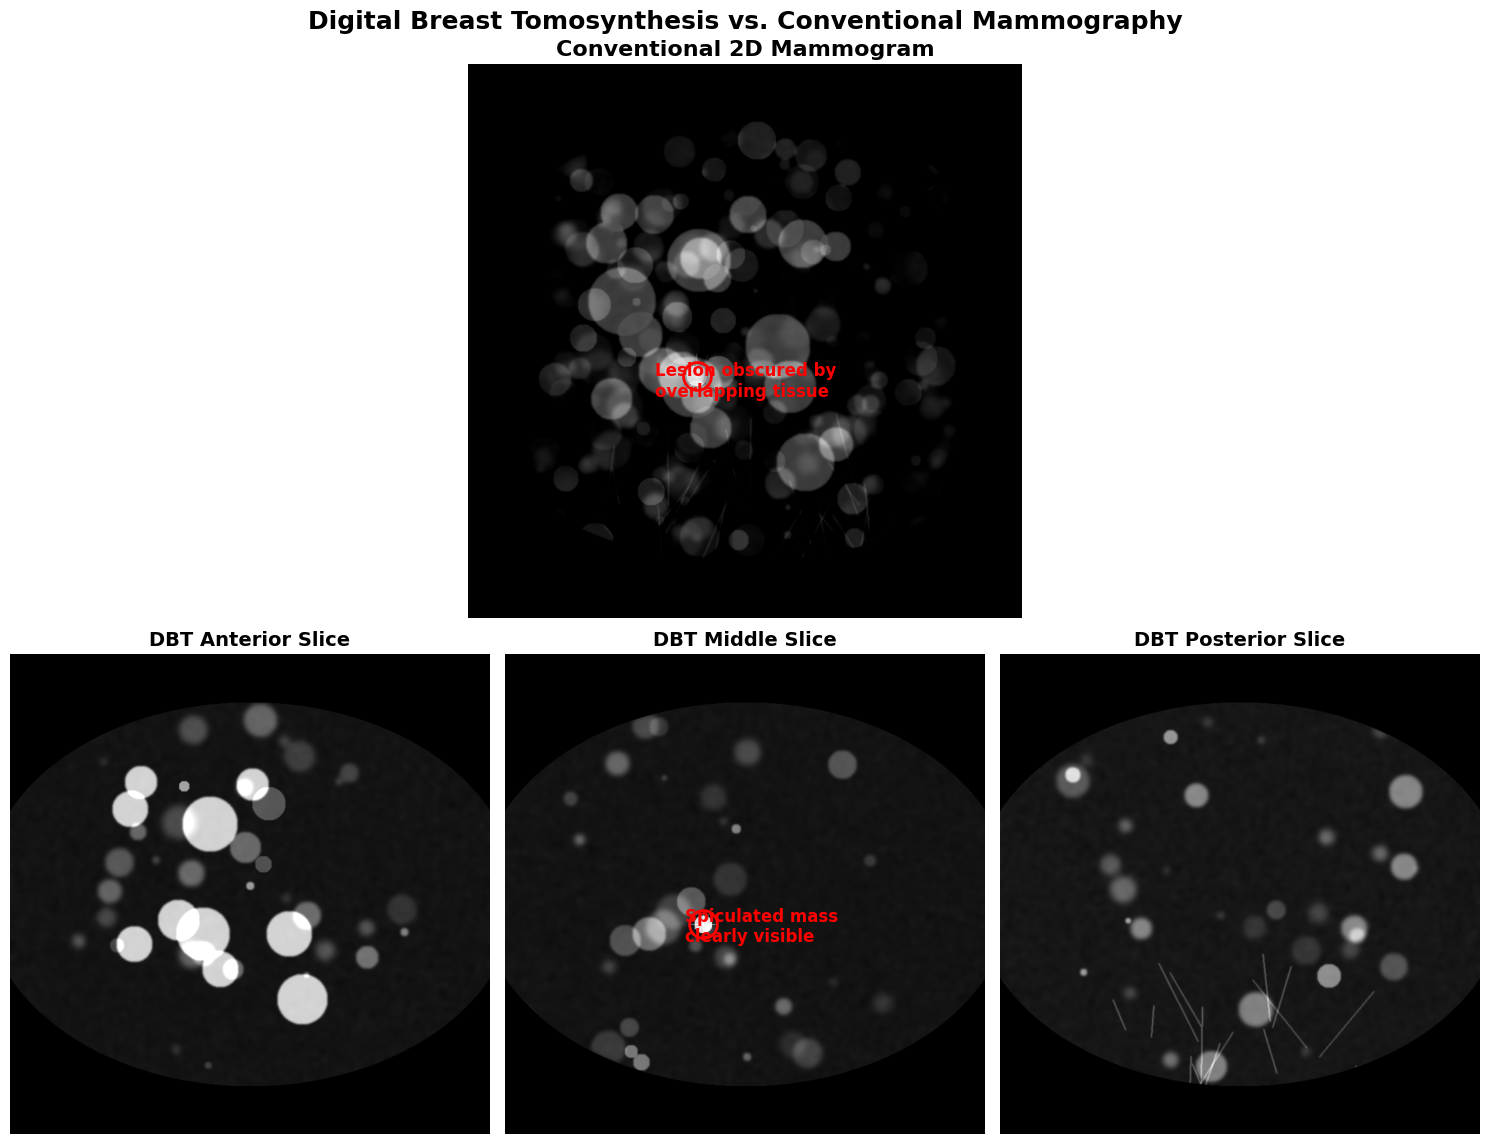

In [15]:
from scipy.ndimage import gaussian_filter
import matplotlib.gridspec as gridspec
from skimage.draw import line, disk, ellipse
from matplotlib.colors import LinearSegmentedColormap

def create_dbt_slice(width=800, height=800, slice_depth=0.5, seed=None):
    """Create a realistic tomosynthesis slice."""
    if seed is not None:
        np.random.seed(seed)
    
    # Create empty image
    image = np.zeros((height, width))
    
    # Create breast outline
    breast_mask = np.zeros((height, width), dtype=bool)
    
    # Create breast shape - more realistic oval
    center_x, center_y = height // 2, width // 2
    for i in range(height):
        for j in range(width):
            # Create elliptical breast boundary
            normalized_x = (i - center_x) / (height/2.5)
            normalized_y = (j - center_y) / (width/1.8)
            if normalized_x**2 + normalized_y**2 < 1:
                breast_mask[i, j] = True
    
    # Base tissue texture
    texture = np.random.normal(0.15, 0.05, (height, width))
    texture = gaussian_filter(texture, sigma=4)
    
    # In-focus structures for this slice - will be sharper
    slice_focus = 0.2 + 0.6 * slice_depth  # Relative position within the breast
    focal_depth = height * slice_focus
    
    # Create structures at different depths - unique to each slice
    # Each slice will have some structures that are uniquely in focus
    for _ in range(80):
        cx = np.random.randint(height//8, 7*height//8)
        cy = np.random.randint(width//8, 7*width//8)
        
        # Structure depth - determines which slice it's most visible in
        # This will create depth-specific structures
        structure_depth_pct = np.random.random()  # 0 to 1
        structure_depth = height * structure_depth_pct
        
        # Calculate blur based on distance from focal plane
        depth_diff = abs(structure_depth - focal_depth)
        depth_factor = depth_diff / (height * 0.3)  # Normalized difference
        
        # If the structure is close to this slice's depth, make it clearer
        # If it's far, make it very blurry or not visible at all
        if depth_factor < 0.7:  # Only show structures relatively close to this slice
            blur_sigma = 0.5 + depth_factor * 8  # More distant = more blurry
            
            # Reduce density for out-of-focus structures
            density_factor = 1.0 - depth_factor * 0.8
            
            # Create structure shape
            radius = np.random.randint(5, 30)
            rr, cc = disk((cx, cy), radius)
            valid_pts = (rr < height) & (cc < width) & (rr >= 0) & (cc >= 0) & breast_mask[rr, cc]
            
            if np.any(valid_pts):
                # Create structure
                struct_image = np.zeros_like(image)
                density = np.random.uniform(0.1, 0.4) * density_factor
                struct_image[rr[valid_pts], cc[valid_pts]] = density
                
                # Blur based on distance from focal plane
                struct_image = gaussian_filter(struct_image, sigma=blur_sigma)
                
                # Add to main image
                image += struct_image
    
    # Add specific structures to each slice depth
    if slice_depth < 0.3:  # Anterior slice
        # Add more structures in anterior region
        for _ in range(10):
            cx = np.random.randint(height//4, 3*height//4)
            cy = np.random.randint(width//4, 3*width//4)
            radius = np.random.randint(20, 50)
            rr, cc = disk((cx, cy), radius)
            valid_pts = (rr < height) & (cc < width) & (rr >= 0) & (cc >= 0) & breast_mask[rr, cc]
            if np.any(valid_pts):
                # Create bright anterior structures
                struct_image = np.zeros_like(image)
                struct_image[rr[valid_pts], cc[valid_pts]] = 0.5
                struct_image = gaussian_filter(struct_image, sigma=1.5)  # Sharp
                image += struct_image
                
    elif 0.4 < slice_depth < 0.6:  # Middle slice - add spiculated mass
        # Add a finding (spiculated mass) visible only in middle slices
        mass_x, mass_y = height//2 + 50, width//2 - 70
        mass_radius = 15
        
        # Create central mass
        rr, cc = disk((mass_x, mass_y), mass_radius)
        valid_pts = (rr < height) & (cc < width) & (rr >= 0) & (cc >= 0) & breast_mask[rr, cc]
        if np.any(valid_pts):
            image[rr[valid_pts], cc[valid_pts]] += 0.5  # Make it clearly visible
            
            # Add spiculations
            for i in range(12):
                angle = i * np.pi/6
                length = np.random.randint(15, 35)
                end_x = int(mass_x + length * np.cos(angle))
                end_y = int(mass_y + length * np.sin(angle))
                
                rr, cc = line(mass_x, mass_y, end_x, end_y)
                valid_pts = (rr < height) & (cc < width) & (rr >= 0) & (cc >= 0) & breast_mask[rr, cc]
                if np.any(valid_pts):
                    image[rr[valid_pts], cc[valid_pts]] += 0.4
    
    elif slice_depth > 0.7:  # Posterior slice
        # Add structures near chest wall
        for _ in range(15):
            # Create linear structures in posterior region
            start_x = np.random.randint(3*height//4, height-20)
            start_y = np.random.randint(width//4, 3*width//4)
            length = np.random.randint(50, 150)
            angle = np.random.uniform(-np.pi/4, np.pi/4)
            end_x = int(start_x - length * np.cos(angle))
            end_y = int(start_y + length * np.sin(angle))
            
            rr, cc = line(start_x, start_y, min(height-1, max(0, end_x)), min(width-1, max(0, end_y)))
            valid_pts = (rr < height) & (cc < width) & (rr >= 0) & (cc >= 0) & breast_mask[rr, cc]
            if np.any(valid_pts):
                struct_image = np.zeros_like(image)
                struct_image[rr[valid_pts], cc[valid_pts]] = 0.4
                struct_image = gaussian_filter(struct_image, sigma=1.0)  # Sharp
                image += struct_image
    
    # Apply texture only inside the mask
    result = np.zeros_like(image)
    result[breast_mask] = texture[breast_mask] + image[breast_mask]
    
    # Enhance contrast
    result = np.clip((result - 0.1) * 1.5, 0, 1)
    
    return result

def create_conventional_mammogram(width=800, height=800, seed=None):
    """Create a synthetic conventional mammogram (all slices superimposed)"""
    if seed is not None:
        np.random.seed(seed)
    
    # Superimpose multiple slices to simulate conventional mammogram
    num_slices = 7
    image = np.zeros((height, width))
    
    for i in range(num_slices):
        slice_depth = i / (num_slices - 1)
        # Use different seeds for each slice but ensure reproducibility
        # by deriving from the base seed
        slice_seed = seed + i if seed is not None else None
        image += create_dbt_slice(width, height, slice_depth, seed=slice_seed) / num_slices
    
    # Enhance contrast
    image = np.clip((image - 0.1) * 1.3, 0, 1)
    
    return image

def display_dbt_comparison():
    """Display comparison between DBT and conventional mammography"""
    fig = plt.figure(figsize=(15, 12))
    
    # Custom mammogram colormap
    cmap_colors = [(0, 0, 0), (1, 1, 1)]
    mammogram_cmap = LinearSegmentedColormap.from_list("mammogram", cmap_colors)
    
    # Setup grid
    gs = gridspec.GridSpec(2, 3)
    
    # Show conventional mammogram
    ax_conventional = plt.subplot(gs[0, :])
    conventional = create_conventional_mammogram(seed=42)
    ax_conventional.imshow(conventional, cmap=mammogram_cmap)
    ax_conventional.set_title('Conventional 2D Mammogram', fontsize=16, fontweight='bold')
    ax_conventional.axis('off')
    
    # Add annotation for obscured lesion
    ax_conventional.plot(400-70, 400+50, 'ro', markerfacecolor='none', markersize=20, markeredgewidth=2)
    ax_conventional.text(400-130, 400+80, "Lesion obscured by\noverlapping tissue", 
                         color='red', fontsize=12, fontweight='bold')
    
    # Show DBT slices
    slices = [0.2, 0.5, 0.8]  # Anterior, middle, posterior
    slice_titles = ["DBT Anterior Slice", "DBT Middle Slice", "DBT Posterior Slice"]
    
    for i, (depth, title) in enumerate(zip(slices, slice_titles)):
        ax = plt.subplot(gs[1, i])
        # Use base seed + different values for each slice
        dbt_slice = create_dbt_slice(slice_depth=depth, seed=42+i*100)
        ax.imshow(dbt_slice, cmap=mammogram_cmap)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')
        
        # Add annotation for the lesion in the middle slice
        if i == 1:  # Middle slice
            ax.plot(400-70, 400+50, 'ro', markerfacecolor='none', markersize=20, markeredgewidth=2)
            ax.text(400-100, 400+80, "Spiculated mass\nclearly visible", 
                    color='red', fontsize=12, fontweight='bold')
    
    plt.suptitle('Digital Breast Tomosynthesis vs. Conventional Mammography', 
                fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Display the comparison
display_dbt_comparison()

## Mammographic Magnification View

### Overview
Magnification mammography is a specialized technique that provides detailed, high-resolution images of suspicious areas identified on standard mammograms. This technique is particularly valuable for evaluating microcalcifications, architectural distortions, and the margins of masses.

### Technical Principles

#### How Magnification is Achieved
1. **Increased Object-to-Image Distance (OID)**:
   - The breast is positioned farther from the image receptor
   - The X-ray tube remains at its standard distance from the receptor
   - This creates geometric magnification of the breast structures

2. **Specialized Compression**:
   - A small compression paddle is used to compress only the area of interest
   - The compression paddle has a raised platform that positions the breast away from the detector

3. **Focal Spot Selection**:
   - A smaller focal spot (0.1mm vs the standard 0.3mm) is used
   - Reduces geometric unsharpness despite the magnification

4. **Modified Technical Factors**:
   - Increased kVp and mAs settings
   - Compensates for the increased distance and smaller focal spot

### Clinical Applications

#### Primary Indications
- **Microcalcifications**:
  - Improved characterization of morphology (shape, size, density)
  - Better assessment of distribution patterns
  - Enhanced detection of subtle calcifications

- **Mass Assessment**:
  - Clearer visualization of margins (circumscribed vs. spiculated)
  - Better delineation between benign and malignant features
  - Improved detection of associated microcalcifications

- **Architectural Distortions**:
  - Enhanced visualization of subtle tissue changes
  - Better assessment of tumor infiltration
  - More clearly defined tissue boundaries

#### Magnification Factors
- Standard magnification: 1.5× to 2.0×
- Typical field of view: 5-10 cm diameter area
- Spatial resolution: Up to 20 line pairs per mm (vs 10-15 in standard mammography)

### Diagnostic Advantages

1. **Improved Diagnostic Confidence**:
   - Reduces the number of "probably benign" assessments
   - Decreases unnecessary biopsies for benign-appearing calcifications
   - Increases detection of subtle malignant features

2. **Better Characterization of Findings**:
   - Microcalcifications can be categorized more accurately
   - Pleomorphic vs. punctate vs. coarse heterogeneous
   - Linear vs. segmental vs. grouped distributions

3. **Preprocessing Benefits**:
   - Reduced tissue superimposition
   - Decreased scatter radiation
   - Enhanced contrast resolution

### Workflow Integration

#### Standard Protocol
1. Suspicious area identified on routine mammogram views (CC, MLO)
2. Spot compression views often performed first
3. Magnification views obtained for areas requiring higher resolution
4. Standard magnification views: CC and lateral or ML

#### Image Interpretation
- Direct side-by-side comparison with standard views
- Assessment of additional calcifications not seen on standard views
- Evaluation of calcification morphology using BI-RADS descriptors
- Documentation of exact size and extent of findings

### Limitations

- Increased radiation dose (2-3× that of standard view)
- Limited field of view
- Requires excellent positioning skills
- Patient discomfort with specialized compression
- Limited to evaluation of specific areas rather than entire breast

Magnification mammography remains an essential problem-solving tool in breast imaging, particularly for the accurate assessment of microcalcifications, despite advances in digital breast tomosynthesis and other 3D imaging techniques.

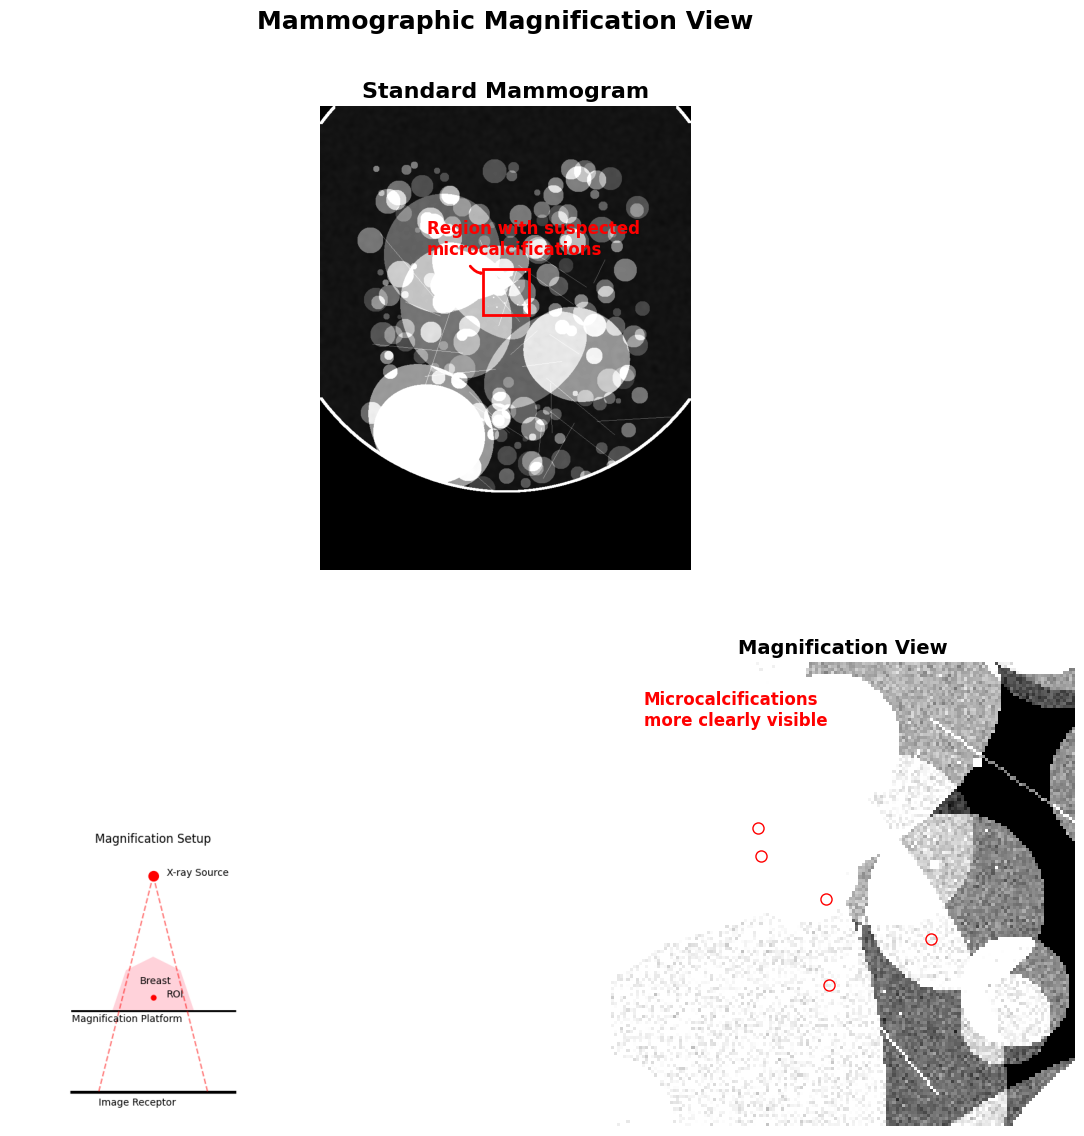

In [16]:
from scipy.ndimage import gaussian_filter
import matplotlib.gridspec as gridspec
from skimage.draw import line, disk, ellipse, polygon
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle, FancyArrowPatch

def create_standard_mammogram(width=800, height=1000, region_of_interest=None, seed=None):
    """Create a synthetic mammogram with optional region of interest"""
    if seed is not None:
        np.random.seed(seed)
    
    # Create empty image
    image = np.zeros((height, width))
    
    # Create breast outline
    breast_mask = np.zeros((height, width), dtype=bool)
    
    # Create breast shape
    center_x, center_y = height // 3, width // 2
    for i in range(height):
        for j in range(width):
            # Create curved breast boundary
            if (i - center_x)**2 + (j - center_y)**2 < (height//2)**2 and i < height - 50:
                breast_mask[i, j] = True
    
    # Base tissue texture
    texture = np.random.normal(0.15, 0.05, (height, width))
    texture = gaussian_filter(texture, sigma=4)
    
    # Add structure to the tissue
    for _ in range(200):
        # Random structures throughout breast
        cx = np.random.randint(height//8, 7*height//8)
        cy = np.random.randint(width//8, 7*width//8)
        
        if breast_mask[cx, cy]:
            radius = np.random.randint(5, 30)
            rr, cc = disk((cx, cy), radius)
            valid_pts = (rr < height) & (cc < width) & (rr >= 0) & (cc >= 0) & breast_mask[rr, cc]
            
            if np.any(valid_pts):
                # Add varied structure
                density = np.random.uniform(0.1, 0.3)
                image[rr[valid_pts], cc[valid_pts]] += density
    
    # Add glandular tissue regions
    for _ in range(8):
        cx = np.random.randint(height//4, 3*height//4)
        cy = np.random.randint(width//4, 3*width//4)
        
        if breast_mask[cx, cy]:
            radius_x = np.random.randint(50, 150)
            radius_y = np.random.randint(50, 150)
            rotation = np.random.uniform(0, np.pi)
            
            rr, cc = ellipse(cx, cy, radius_x, radius_y, rotation=rotation, shape=(height, width))
            valid_pts = (rr < height) & (cc < width) & (rr >= 0) & (cc >= 0) & breast_mask[rr, cc]
            
            if np.any(valid_pts):
                # Add glandular region
                density = np.random.uniform(0.2, 0.4)
                image[rr[valid_pts], cc[valid_pts]] += density
    
    # Add ducts and vessels
    for _ in range(25):
        start_x = np.random.randint(height//4, 3*height//4)
        start_y = np.random.randint(width//4, 3*width//4)
        
        if breast_mask[start_x, start_y]:
            length = np.random.randint(50, 200)
            angle = np.random.uniform(0, 2*np.pi)
            end_x = int(start_x + length * np.cos(angle))
            end_y = int(start_y + length * np.sin(angle))
            
            rr, cc = line(start_x, start_y, min(height-1, max(0, end_x)), min(width-1, max(0, end_y)))
            valid_pts = (rr < height) & (cc < width) & (rr >= 0) & (cc >= 0) & breast_mask[rr, cc]
            
            if np.any(valid_pts):
                image[rr[valid_pts], cc[valid_pts]] += 0.25
    
    # Add region of interest with microcalcifications if specified
    if region_of_interest:
        roi_x, roi_y, roi_size = region_of_interest
        
        # Ensure the ROI is inside the breast
        if breast_mask[roi_x, roi_y]:
            # Create cluster of microcalcifications
            for _ in range(15):
                calc_x = roi_x + np.random.randint(-roi_size//2, roi_size//2)
                calc_y = roi_y + np.random.randint(-roi_size//2, roi_size//2)
                
                if 0 <= calc_x < height and 0 <= calc_y < width and breast_mask[calc_x, calc_y]:
                    # Tiny calcifications
                    radius = np.random.randint(1, 3)
                    rr, cc = disk((calc_x, calc_y), radius)
                    valid_pts = (rr < height) & (cc < width) & (rr >= 0) & (cc >= 0)
                    
                    if np.any(valid_pts):
                        image[rr[valid_pts], cc[valid_pts]] += 0.7  # Make calcifications bright
    
    # Apply texture and image inside the mask
    result = np.zeros_like(image)
    result[breast_mask] = texture[breast_mask] + image[breast_mask]
    
    # Add skin line
    skin = np.zeros_like(breast_mask, dtype=bool)
    dilated = breast_mask.copy()
    eroded = breast_mask.copy()
    
    # Manually create skin boundary
    for i in range(1, 6):  # Adjust thickness as needed
        inner = np.zeros_like(breast_mask)
        for r in range(height):
            for c in range(width):
                if breast_mask[r, c] and not all(breast_mask[max(0, r-i):min(height, r+i+1), max(0, c-i):min(width, c+i+1)].flatten()):
                    inner[r, c] = True
        skin |= inner
    
    # Make skin appear brighter
    result[skin] = 0.8
    
    # Enhance contrast
    result = np.clip((result - 0.1) * 1.5, 0, 1)
    
    return result

def create_magnification_view(width=800, height=800, region_of_interest=None, magnification=1.5, seed=None):
    """Create a synthetic magnification view of a region of interest"""
    if seed is not None:
        np.random.seed(seed)
    
    # Create a standard mammogram with ROI
    standard_image = create_standard_mammogram(width, height, region_of_interest, seed)
    
    # Extract region around ROI
    roi_x, roi_y, roi_size = region_of_interest
    roi_size_magnified = int(roi_size * magnification)
    
    # Determine extraction boundaries
    half_size = roi_size_magnified // 2
    x_min = max(0, roi_x - half_size)
    x_max = min(height, roi_x + half_size)
    y_min = max(0, roi_y - half_size)
    y_max = min(width, roi_y + half_size)
    
    # Extract region
    roi_image = standard_image[x_min:x_max, y_min:y_max]
    
    # For simulation purposes, we'll create a higher resolution version
    # In reality, magnification views have better visibility due to:
    # 1. Increased object-to-image distance
    # 2. Reduced scatter radiation
    # 3. Focal spot blur reduction
    
    # Simulate improved resolution by adding more detail
    h, w = roi_image.shape
    magnified = np.zeros((h, w))
    
    # Add more detail to the magnified view
    for i in range(h):
        for j in range(w):
            if roi_image[i, j] > 0.2:  # For breast tissue
                # Add finer texture detail
                detail = np.random.normal(0, 0.05)
                magnified[i, j] = roi_image[i, j] + detail
            else:
                magnified[i, j] = roi_image[i, j]
    
    # For microcalcifications in ROI, make them more distinct
    if region_of_interest:
        # Recalculate the calcification positions for the ROI view
        local_roi_x = half_size
        local_roi_y = half_size
        local_roi_size = roi_size
        
        # Add more detailed microcalcifications
        for _ in range(20):
            calc_x = local_roi_x + np.random.randint(-local_roi_size//2, local_roi_size//2)
            calc_y = local_roi_y + np.random.randint(-local_roi_size//2, local_roi_size//2)
            
            if 0 <= calc_x < h and 0 <= calc_y < w:
                # Smaller, sharper calcifications in magnification view
                radius = np.random.randint(1, 2)
                rr, cc = disk((calc_x, calc_y), radius)
                valid_pts = (rr < h) & (cc < w) & (rr >= 0) & (cc >= 0)
                
                if np.any(valid_pts):
                    # Sharper, clearer calcifications
                    magnified[rr[valid_pts], cc[valid_pts]] = 0.9  
    
    # Enhance contrast for better visualization
    magnified = np.clip((magnified - 0.1) * 1.5, 0, 1)
    
    return magnified, roi_image

def display_magnification_comparison():
    """Display comparison between standard mammogram and magnification view"""
    # Create figure without tight_layout to avoid warnings
    fig = plt.figure(figsize=(15, 12))
    
    # Custom mammogram colormap
    cmap_colors = [(0, 0, 0), (1, 1, 1)]
    mammogram_cmap = LinearSegmentedColormap.from_list("mammogram", cmap_colors)
    
    # Set up the grid - 2 rows, 2 columns
    gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], width_ratios=[1.5, 0.75, 0.75])
    
    # Define ROI with microcalcifications
    roi_x, roi_y, roi_size = 400, 400, 100
    
    # Create standard mammogram
    standard_mammogram = create_standard_mammogram(
        width=800, height=1000, 
        region_of_interest=(roi_x, roi_y, roi_size), 
        seed=42
    )
    
    # Create magnification view
    magnified_view, roi_standard = create_magnification_view(
        width=800, height=1000,
        region_of_interest=(roi_x, roi_y, roi_size),
        magnification=1.5,
        seed=42
    )
    
    # Show standard mammogram
    ax_standard = plt.subplot(gs[0, :])
    ax_standard.imshow(standard_mammogram, cmap=mammogram_cmap)
    ax_standard.set_title('Standard Mammogram', fontsize=16, fontweight='bold')
    ax_standard.axis('off')
    
    # Add ROI box to standard mammogram
    rect = Rectangle((roi_y-roi_size//2, roi_x-roi_size//2), roi_size, roi_size, 
                    linewidth=2, edgecolor='r', facecolor='none')
    ax_standard.add_patch(rect)
    
    # Add arrow and annotation
    ax_standard.text(roi_y-roi_size//2-120, roi_x-roi_size//2-30, 
                    "Region with suspected\nmicrocalcifications", 
                    color='red', fontsize=12, fontweight='bold')
    
    arrow = FancyArrowPatch((roi_y-roi_size//2-30, roi_x-roi_size//2-10), 
                           (roi_y-roi_size//2+10, roi_x-roi_size//2+10),
                           connectionstyle="arc3,rad=0.3", 
                           arrowstyle="->", color='red', linewidth=2)
    ax_standard.add_patch(arrow)
    
    # Show ROI from standard view
    ax_roi = plt.subplot(gs[1, 0])
    ax_roi.imshow(roi_standard, cmap=mammogram_cmap)
    ax_roi.set_title('Region of Interest (Standard View)', fontsize=14, fontweight='bold')
    ax_roi.axis('off')
    
    # Show magnification view
    ax_mag = plt.subplot(gs[1, 1:])
    ax_mag.imshow(magnified_view, cmap=mammogram_cmap)
    ax_mag.set_title('Magnification View', fontsize=14, fontweight='bold')
    ax_mag.axis('off')
    
    # Add annotations for microcalcifications in magnification view
    for i in range(5):
        x = magnified_view.shape[0]//2 + np.random.randint(-30, 30)
        y = magnified_view.shape[1]//2 + np.random.randint(-30, 30)
        ax_mag.plot(y, x, 'o', markersize=8, markeredgecolor='red', markerfacecolor='none')
    
    ax_mag.text(10, 20, "Microcalcifications\nmore clearly visible", 
               color='red', fontsize=12, fontweight='bold')
    
    # Create a separate figure for the diagram
    # Instead of using add_axes which causes tight_layout warnings
    diagram_ax = plt.subplot(gs[1, 0])
    diagram_ax.set_visible(False)  # Hide this axis
    
    # Create a new figure for the diagram
    diag_fig = plt.figure(figsize=(5, 5))
    ax_diagram = diag_fig.add_subplot(111)
    ax_diagram.set_xlim(0, 10)
    ax_diagram.set_ylim(0, 10)
    ax_diagram.axis('off')
    
    # Draw the magnification setup
    # X-ray source
    ax_diagram.plot(5, 9, 'ro', markersize=10)
    ax_diagram.text(5.5, 9, "X-ray Source", fontsize=10)
    
    # Breast platform
    ax_diagram.plot([2, 8], [4, 4], 'k-', linewidth=2)
    ax_diagram.text(2, 3.6, "Magnification Platform", fontsize=10)
    
    # Breast outline
    breast_x = [3.5, 4, 5, 6, 6.5]
    breast_y = [4, 5.5, 6, 5.5, 4]
    ax_diagram.fill(breast_x, breast_y, 'pink', alpha=0.7)
    ax_diagram.text(4.5, 5, "Breast", fontsize=10)
    
    # ROI
    ax_diagram.plot(5, 4.5, 'ro', markersize=5)
    ax_diagram.text(5.5, 4.5, "ROI", fontsize=10)
    
    # Detector
    ax_diagram.plot([2, 8], [1, 1], 'k-', linewidth=3)
    ax_diagram.text(3, 0.5, "Image Receptor", fontsize=10)
    
    # Magnification rays
    ax_diagram.plot([5, 3], [9, 1], 'r--', alpha=0.5)
    ax_diagram.plot([5, 7], [9, 1], 'r--', alpha=0.5)
    
    ax_diagram.set_title("Magnification Setup", fontsize=12)
    
    # Save the diagram
    diag_fig.savefig('magnification_diagram.png', bbox_inches='tight')
    plt.close(diag_fig)  # Close the diagram figure
    
    # Load the diagram as an image and place it in the main figure
    from matplotlib.image import imread
    try:
        diagram_img = imread('magnification_diagram.png')
        diagram_inset = fig.add_axes([0.14, 0.05, 0.25, 0.25])
        diagram_inset.imshow(diagram_img)
        diagram_inset.axis('off')
    except:
        # If saving/loading the diagram fails, just add text explanation
        diagram_text = plt.figtext(0.14, 0.15, "Magnification Setup:\n" +
                               "- X-ray source at top\n" +
                               "- Breast on elevated platform\n" +
                               "- Increased object-to-image distance\n" +
                               "- Image receptor at bottom", 
                               fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.suptitle('Mammographic Magnification View', fontsize=18, fontweight='bold', y=0.98)
    
    # Use subplots_adjust instead of tight_layout to avoid warnings
    plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.1, hspace=0.2)
    plt.show()

# Display the magnification view comparison
display_magnification_comparison()

## Spot Compression View in Mammography

### Overview
Spot compression (also called focal compression or cone compression) is a supplementary mammographic technique that applies focused pressure to a specific area of concern within the breast. This targeted compression helps to separate overlapping tissues and enhance visualization of suspicious findings.

### Clinical Purpose

#### Primary Uses
- **Characterize Masses**: Clarify the margins and internal characteristics of masses
- **Evaluate Asymmetries**: Determine if an asymmetry represents summation artifact or true finding
- **Investigate Architectural Distortions**: Better define tissue alterations
- **Differentiate Real vs. Apparent Lesions**: Determine if a potential lesion disappears with compression
- **Enhance Visibility**: Improve visualization of partially obscured lesions

#### Problem-Solving Benefits
- **Reduced Callbacks**: Can often resolve questionable findings at the initial exam
- **Improved Specificity**: Better characterization of benign vs. malignant features
- **Enhanced Diagnostic Confidence**: More definitive assessment of findings

### Technical Aspects

#### Equipment and Technique
- **Specialized Paddle**: Uses a small compression paddle (typically 5-7 cm diameter)
- **Focused Pressure**: Applies compression to a localized area rather than the entire breast
- **Positioning**: Targets the specific area of concern identified on standard views
- **Exposure Factors**: Often requires adjusted technical factors compared to standard views

#### Mechanisms of Improvement
1. **Tissue Separation**: Spreads overlapping structures apart
2. **Decreased Tissue Thickness**: Reduces beam hardening and scatter radiation
3. **Immobilization**: Decreases motion blur
4. **Enhanced Detail**: Improves spatial resolution
5. **Margin Clarification**: Better delineates borders of masses

### Clinical Applications

#### Mass Characterization
- **Margin Assessment**: Helps distinguish between:
  - Circumscribed (suggesting benign)
  - Indistinct (intermediate suspicion)
  - Spiculated (suggesting malignancy)
- **Internal Characteristics**: Enhances visualization of:
  - Homogeneity/heterogeneity
  - Calcifications within masses
  - Fat within masses (suggesting benign lesions like lipomas)

#### Asymmetry Evaluation
- **Summation Artifact**: Will disappear with spot compression
- **True Finding**: Will persist and often show better definition with compression
- **Developing Asymmetry**: Allows comparison with prior examinations

#### Architectural Distortion Assessment
- **Enhanced Visibility**: Makes subtle distortions more conspicuous
- **Border Definition**: Clarifies the extent of tissue alteration
- **Associated Findings**: Improves detection of related calcifications or masses

### Workflow Integration

#### Standard Protocol
1. Abnormality identified on routine screening views
2. Spot compression applied to the area of concern
3. Images evaluated for improved characterization
4. Further imaging (magnification, ultrasound) performed if needed

#### Image Interpretation
- Direct comparison with the corresponding area on standard views
- Assessment of persistence vs. disappearance of the finding
- Evaluation of margin characteristics and internal features
- Application of BI-RADS descriptors and assessment categories

### Limitations

- Limited field of view
- Patient discomfort from intense focal pressure
- Not suitable for very superficial or very posterior lesions
- May not adequately demonstrate lesions in dense tissue
- Cannot replace other techniques for certain findings (e.g., microcalcifications require magnification)

### Comparison with Other Special Views

| Technique | Best For | Limitations |
|-----------|----------|-------------|
| Spot Compression | Masses, asymmetries, architectural distortions | Smaller field of view, cannot magnify |
| Magnification | Microcalcifications, subtle findings | Higher radiation dose, no increased compression |
| Exaggerated CC (XCCL) | Lateral breast findings | Limited to specific location |
| Cleavage View (CV) | Medial findings near chest wall | Cannot visualize entire breast |

Spot compression remains one of the most frequently performed supplementary mammographic techniques, often serving as the first step in the evaluation of questionable findings detected on standard views.

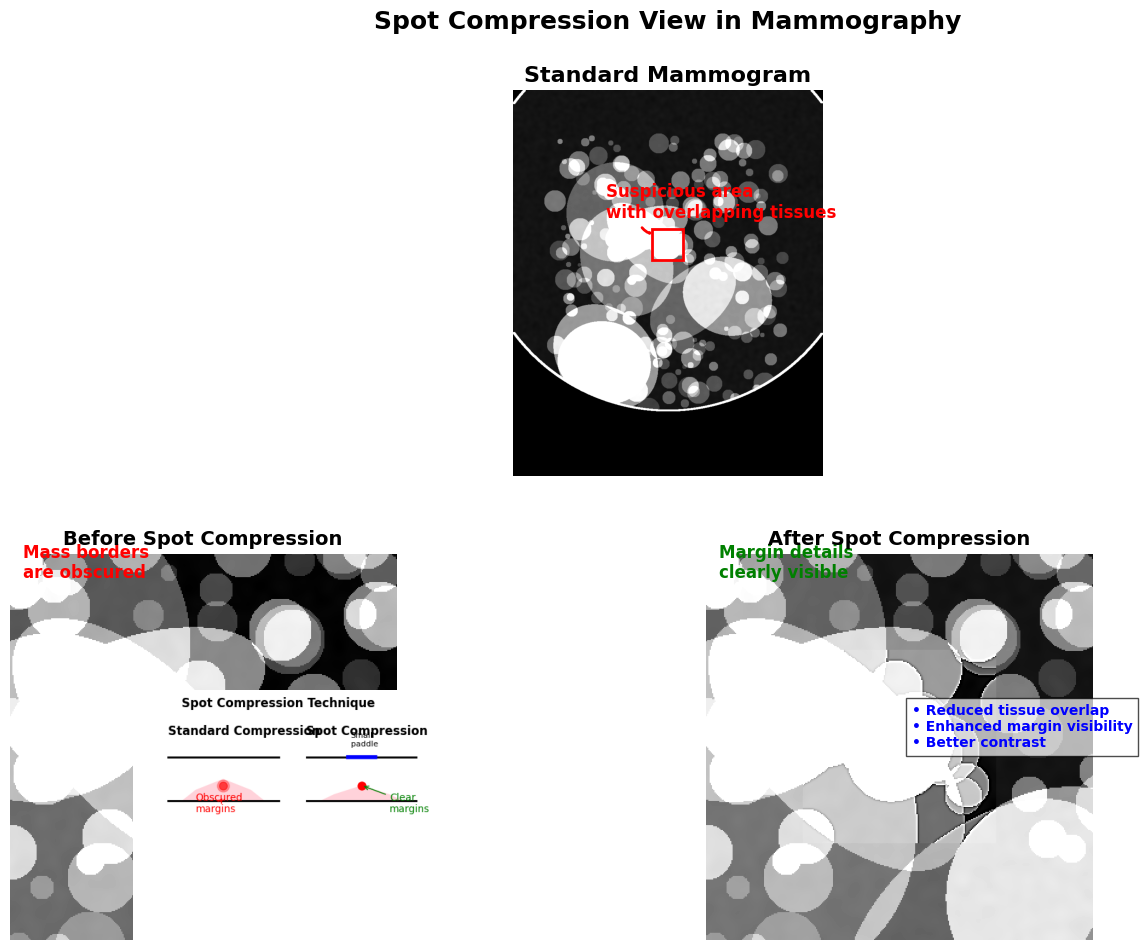

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.gridspec as gridspec
from skimage.draw import line, disk, ellipse
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle, FancyArrowPatch

def create_standard_mammogram(width=800, height=1000, region_of_interest=None, seed=None):
    """Create a synthetic mammogram with optional region of interest"""
    if seed is not None:
        np.random.seed(seed)
    
    # Create empty image
    image = np.zeros((height, width))
    
    # Create breast outline
    breast_mask = np.zeros((height, width), dtype=bool)
    
    # Create breast shape
    center_x, center_y = height // 3, width // 2
    for i in range(height):
        for j in range(width):
            # Create curved breast boundary
            if (i - center_x)**2 + (j - center_y)**2 < (height//2)**2 and i < height - 50:
                breast_mask[i, j] = True
    
    # Base tissue texture
    texture = np.random.normal(0.15, 0.05, (height, width))
    texture = gaussian_filter(texture, sigma=4)
    
    # Add structure to the tissue
    for _ in range(200):
        # Random structures throughout breast
        cx = np.random.randint(height//8, 7*height//8)
        cy = np.random.randint(width//8, 7*width//8)
        
        if breast_mask[cx, cy]:
            radius = np.random.randint(5, 30)
            rr, cc = disk((cx, cy), radius)
            valid_pts = (rr < height) & (cc < width) & (rr >= 0) & (cc >= 0) & breast_mask[rr, cc]
            
            if np.any(valid_pts):
                # Add varied structure
                density = np.random.uniform(0.1, 0.3)
                image[rr[valid_pts], cc[valid_pts]] += density
    
    # Add glandular tissue regions
    for _ in range(8):
        cx = np.random.randint(height//4, 3*height//4)
        cy = np.random.randint(width//4, 3*width//4)
        
        if breast_mask[cx, cy]:
            radius_x = np.random.randint(50, 150)
            radius_y = np.random.randint(50, 150)
            rotation = np.random.uniform(0, np.pi)
            
            rr, cc = ellipse(cx, cy, radius_x, radius_y, rotation=rotation, shape=(height, width))
            valid_pts = (rr < height) & (cc < width) & (rr >= 0) & (cc >= 0) & breast_mask[rr, cc]
            
            if np.any(valid_pts):
                # Add glandular region
                density = np.random.uniform(0.2, 0.4)
                image[rr[valid_pts], cc[valid_pts]] += density
    
    # Add a suspicious mass if ROI is specified
    if region_of_interest:
        roi_x, roi_y, roi_size = region_of_interest
        
        # Ensure the ROI is inside the breast
        if breast_mask[roi_x, roi_y]:
            # Create focal asymmetry or mass
            mass_radius = roi_size // 2
            mass_shape = ellipse(roi_x, roi_y, mass_radius, mass_radius * 1.2, 
                                rotation=np.pi/4, shape=(height, width))
            rr, cc = mass_shape
            valid_pts = (rr < height) & (cc < width) & (rr >= 0) & (cc >= 0) & breast_mask[rr, cc]
            
            if np.any(valid_pts):
                # Make it appear somewhat obscured
                image[rr[valid_pts], cc[valid_pts]] += 0.35
                
                # Add some overlapping structures to make it harder to see
                for _ in range(5):
                    cx = roi_x + np.random.randint(-roi_size//2, roi_size//2)
                    cy = roi_y + np.random.randint(-roi_size//2, roi_size//2)
                    if breast_mask[cx, cy]:
                        radius = np.random.randint(10, 25)
                        overlay_rr, overlay_cc = disk((cx, cy), radius)
                        valid_overlay = (overlay_rr < height) & (overlay_cc < width) & \
                                       (overlay_rr >= 0) & (overlay_cc >= 0) & \
                                       breast_mask[overlay_rr, overlay_cc]
                        if np.any(valid_overlay):
                            image[overlay_rr[valid_overlay], overlay_cc[valid_overlay]] += 0.2
    
    # Apply texture and image inside the mask
    result = np.zeros_like(image)
    result[breast_mask] = texture[breast_mask] + image[breast_mask]
    
    # Add skin line
    skin = np.zeros_like(breast_mask, dtype=bool)
    for i in range(1, 6):
        inner = np.zeros_like(breast_mask)
        for r in range(height):
            for c in range(width):
                if breast_mask[r, c] and not all(breast_mask[max(0, r-i):min(height, r+i+1), 
                                                          max(0, c-i):min(width, c+i+1)].flatten()):
                    inner[r, c] = True
        skin |= inner
    
    # Make skin appear brighter
    result[skin] = 0.8
    
    # Enhance contrast
    result = np.clip((result - 0.1) * 1.5, 0, 1)
    
    return result

def create_spot_compression_view(standard_image, region_of_interest):
    """Create a spot compression view from a standard mammogram"""
    roi_x, roi_y, roi_size = region_of_interest
    
    # Make a copy of the original
    spot_image = standard_image.copy()
    height, width = spot_image.shape
    
    # Area to apply compression effect
    x_min = max(0, roi_x - roi_size)
    x_max = min(height, roi_x + roi_size)
    y_min = max(0, roi_y - roi_size)
    y_max = min(width, roi_y + roi_size)
    
    # In spot compression:
    # 1. Tissues are spread out
    # 2. Overlapping structures are separated
    # 3. Margin details are enhanced
    
    # Extract the ROI
    roi = spot_image[x_min:x_max, y_min:y_max]
    
    # Enhance contrast in the compressed area
    roi = np.clip((roi - roi.min()) / (roi.max() - roi.min() + 1e-10), 0, 1)
    roi = np.power(roi, 0.8)  # Gamma correction to enhance contrast
    
    # Apply median filter to reduce noise but preserve edges
    from scipy.ndimage import median_filter
    roi = median_filter(roi, size=2)
    
    # Apply edge enhancement
    from scipy.ndimage import gaussian_filter
    blurred = gaussian_filter(roi, sigma=1)
    highpass = roi - blurred
    roi_enhanced = np.clip(roi + highpass * 2, 0, 1)
    
    # Replace the ROI in the original image
    spot_image[x_min:x_max, y_min:y_max] = roi_enhanced
    
    # Focus in on the ROI for the final image
    # Extract a slightly larger area for context
    context_size = roi_size * 2
    x_min_context = max(0, roi_x - context_size)
    x_max_context = min(height, roi_x + context_size)
    y_min_context = max(0, roi_y - context_size)
    y_max_context = min(width, roi_y + context_size)
    
    roi_with_context = spot_image[x_min_context:x_max_context, y_min_context:y_max_context]
    
    return roi_with_context, roi_enhanced

def display_spot_compression_comparison():
    """Display comparison between standard mammogram and spot compression view"""
    # Create figure
    fig = plt.figure(figsize=(15, 10))
    
    # Custom mammogram colormap
    cmap_colors = [(0, 0, 0), (1, 1, 1)]
    mammogram_cmap = LinearSegmentedColormap.from_list("mammogram", cmap_colors)
    
    # Set up the grid
    gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1])
    
    # Define ROI with a suspicious mass
    roi_x, roi_y, roi_size = 400, 400, 80
    
    # Create standard mammogram
    standard_mammogram = create_standard_mammogram(
        width=800, height=1000, 
        region_of_interest=(roi_x, roi_y, roi_size), 
        seed=42
    )
    
    # Create spot compression view
    spot_view_context, spot_view_roi = create_spot_compression_view(
        standard_mammogram,
        region_of_interest=(roi_x, roi_y, roi_size)
    )
    
    # Show standard mammogram
    ax_standard = plt.subplot(gs[0, :])
    ax_standard.imshow(standard_mammogram, cmap=mammogram_cmap)
    ax_standard.set_title('Standard Mammogram', fontsize=16, fontweight='bold')
    ax_standard.axis('off')
    
    # Add ROI box to standard mammogram
    rect = Rectangle((roi_y-roi_size//2, roi_x-roi_size//2), roi_size, roi_size, 
                    linewidth=2, edgecolor='r', facecolor='none')
    ax_standard.add_patch(rect)
    
    # Add arrow and annotation
    ax_standard.text(roi_y-roi_size//2-120, roi_x-roi_size//2-30, 
                    "Suspicious area\nwith overlapping tissues", 
                    color='red', fontsize=12, fontweight='bold')
    
    arrow = FancyArrowPatch((roi_y-roi_size//2-30, roi_x-roi_size//2-10), 
                           (roi_y-roi_size//2+10, roi_x-roi_size//2+10),
                           connectionstyle="arc3,rad=0.3", 
                           arrowstyle="->", color='red', linewidth=2)
    ax_standard.add_patch(arrow)
    
    # Show the area with context before spot compression
    roi_context_standard = standard_mammogram[
        max(0, roi_x - roi_size*2):min(1000, roi_x + roi_size*2),
        max(0, roi_y - roi_size*2):min(800, roi_y + roi_size*2)
    ]
    ax_roi_standard = plt.subplot(gs[1, 0])
    ax_roi_standard.imshow(roi_context_standard, cmap=mammogram_cmap)
    ax_roi_standard.set_title('Before Spot Compression', fontsize=14, fontweight='bold')
    ax_roi_standard.axis('off')
    
    # Add annotation on pre-compression image
    ax_roi_standard.text(10, 20, "Mass borders\nare obscured", 
                        color='red', fontsize=12, fontweight='bold')
    
    # Show spot compression view
    ax_spot = plt.subplot(gs[1, 1:])
    ax_spot.imshow(spot_view_context, cmap=mammogram_cmap)
    ax_spot.set_title('After Spot Compression', fontsize=14, fontweight='bold')
    ax_spot.axis('off')
    
    # Add annotation on post-compression
    ax_spot.text(10, 20, "Margin details\nclearly visible", 
                color='green', fontsize=12, fontweight='bold')
    
    # Add second annotation showing specific features
    ax_spot.text(spot_view_context.shape[1]-150, spot_view_context.shape[0]//2, 
                "• Reduced tissue overlap\n• Enhanced margin visibility\n• Better contrast", 
                color='blue', fontsize=10, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7))
    
    # Create diagram showing spot compression technique
    diagram_fig = plt.figure(figsize=(5, 4))
    ax_diagram = diagram_fig.add_subplot(111)
    ax_diagram.set_xlim(0, 10)
    ax_diagram.set_ylim(0, 10)
    ax_diagram.axis('off')
    
    # Draw standard compression
    ax_diagram.text(1, 9, "Standard Compression", fontsize=12, fontweight='bold')
    ax_diagram.plot([1, 5], [8, 8], 'k-', linewidth=2)  # Top compression paddle
    ax_diagram.plot([1, 5], [6, 6], 'k-', linewidth=2)  # Bottom plate
    
    # Draw breast with mass in standard compression
    breast_x = [1.5, 2, 3, 4, 4.5]
    breast_y = [6, 6.5, 7, 6.5, 6]
    ax_diagram.fill(breast_x, breast_y, 'pink', alpha=0.7)
    
    # Add mass in breast that's obscured
    ax_diagram.plot(3, 6.7, 'ro', markersize=8, alpha=0.6)
    ax_diagram.plot(3, 6.7, 'ro', markersize=12, alpha=0.3)  # Fuzzy margin effect
    
    # Draw spot compression
    ax_diagram.text(6, 9, "Spot Compression", fontsize=12, fontweight='bold')
    ax_diagram.plot([6, 10], [8, 8], 'k-', linewidth=2)  # Top compression paddle
    ax_diagram.plot([6, 10], [6, 6], 'k-', linewidth=2)  # Bottom plate
    
    # Add small compression paddle
    ax_diagram.plot([7.5, 8.5], [8, 8], 'b-', linewidth=4)  # Small paddle
    
    # Draw breast with mass in spot compression
    breast_x2 = [6.5, 7, 7.5, 8, 8.5, 9, 9.5]
    breast_y2 = [6, 6.3, 6.5, 6.7, 6.5, 6.3, 6]
    ax_diagram.fill(breast_x2, breast_y2, 'pink', alpha=0.7)
    
    # Add mass in breast that's now clearly visible
    ax_diagram.plot(8, 6.7, 'ro', markersize=8)
    
    # Add annotations
    ax_diagram.annotate("Obscured\nmargins", (3, 6.2), (2, 5.5), 
                      arrowprops=dict(arrowstyle="->", color='red'), color='red')
    
    ax_diagram.annotate("Clear\nmargins", (8, 6.7), (9, 5.5),
                      arrowprops=dict(arrowstyle="->", color='green'), color='green')
    
    # Add small compression paddle label
    ax_diagram.text(7.6, 8.5, "Small\npaddle", fontsize=8)
    
    ax_diagram.set_title("Spot Compression Technique", fontsize=12, fontweight='bold')
    
    # Save the diagram 
    diagram_fig.savefig('spot_compression_diagram.png', bbox_inches='tight')
    plt.close(diagram_fig)  # Close the diagram figure
    
    # Load and add the diagram to the main figure
    from matplotlib.image import imread
    try:
        diagram_img = imread('spot_compression_diagram.png')
        diagram_inset = fig.add_axes([0.12, 0.05, 0.25, 0.25])
        diagram_inset.imshow(diagram_img)
        diagram_inset.axis('off')
    except:
        # Fallback if image saving/loading fails
        diagram_text = plt.figtext(0.12, 0.15, "Spot Compression Technique:\n" +
                               "- Small compression paddle\n" +
                               "- Focused pressure on suspicious area\n" +
                               "- Spreads tissues\n" +
                               "- Enhances margin visibility", 
                               fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.suptitle('Spot Compression View in Mammography', 
                fontsize=18, fontweight='bold', y=0.98)
    
    # Adjust layout
    plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.1, hspace=0.2)
    plt.show()

# Display the comparison
display_spot_compression_comparison()

# Mammography Performance Metrics and Evaluation

## Understanding Recall in Mammography

In breast imaging, **recall** (sometimes called "callback") occurs when a radiologist identifies a suspicious finding on a screening mammogram and requests additional imaging for further evaluation. This process is a critical balance between:
- Detecting clinically significant cancers (sensitivity)
- Minimizing unnecessary additional testing (specificity)

## Standard Performance Metrics

### Fundamental Metrics

| Classification | Cancer Present | Cancer Absent |
|----------------|----------------|---------------|
| Test Positive (Recall) | True Positive (TP) | False Positive (FP) |
| Test Negative (No Recall) | False Negative (FN) | True Negative (TN) |

### Key Performance Equations

1. **Sensitivity (Cancer Detection Rate)**
   - Proportion of actual cancers correctly identified
   - $\text{Sensitivity} = \frac{TP}{TP + FN} \times 100\%$
   - Goal: >85% for digital mammography

2. **Specificity**
   - Proportion of non-cancers correctly identified as normal
   - $\text{Specificity} = \frac{TN}{TN + FP} \times 100\%$
   - Goal: >90% for screening mammography

3. **Recall Rate**
   - Percentage of screening examinations resulting in additional imaging
   - $\text{Recall Rate} = \frac{TP + FP}{Total\ Examinations} \times 100\%$
   - Benchmark: 5-12% (first screening), <7% (subsequent screenings)

4. **Positive Predictive Value (PPV)**
   - Probability that a positive test reflects true cancer
   - Multiple levels in mammography:
     - PPV1: $\frac{TP}{TP + FP} \times 100\%$ (probability of cancer among those recalled)
     - PPV2: $\frac{TP}{Total\ Biopsies\ Recommended} \times 100\%$ (probability of cancer among those recommended for biopsy)
     - PPV3: $\frac{TP}{Total\ Biopsies\ Performed} \times 100\%$ (probability of cancer among those who had biopsies)
   - Benchmarks: PPV1 5-10%, PPV2 25-40%, PPV3 30-50%

5. **Negative Predictive Value (NPV)**
   - Probability that a negative test reflects true absence of cancer
   - $\text{NPV} = \frac{TN}{TN + FN} \times 100\%$
   - Typically >99% for screening mammography

6. **Accuracy**
   - Overall proportion of correct assessments
   - $\text{Accuracy} = \frac{TP + TN}{Total\ Examinations} \times 100\%$

### Advanced Metrics

7. **Cancer Detection Rate (CDR)**
   - Number of cancers detected per 1,000 screening examinations
   - $\text{CDR} = \frac{Number\ of\ Cancers\ Detected}{Number\ of\ Women\ Screened} \times 1,000$
   - Benchmark: >5 per 1,000 for first screening, >3 per 1,000 for subsequent screenings

8. **Interval Cancer Rate**
   - Cancers appearing between screening rounds after a negative screen
   - $\text{Interval\ Cancer\ Rate} = \frac{Number\ of\ Interval\ Cancers}{Number\ of\ Negative\ Screens} \times 100\%$
   - Goal: <1 per 1,000 negative screens

9. **Abnormal Interpretation Rate (AIR)**
   - Another term for recall rate, used in some auditing systems

## Balancing Performance Metrics

### The Sensitivity-Specificity Tradeoff
- Increasing sensitivity (detecting more cancers) typically decreases specificity (more false positives)
- Illustrated by the Receiver Operating Characteristic (ROC) curve
- Area Under the Curve (AUC): Quantifies diagnostic performance independent of threshold

### Impact of Recall Rates

| Recall Rate | Potential Impact |
|-------------|------------------|
| Too Low (<5%) | May miss cancers (decreased sensitivity) |
| Optimal (5-12% initial, <7% subsequent) | Balance between cancer detection and unnecessary procedures |
| Too High (>12%) | Increases patient anxiety, costs, unnecessary procedures |

## Factors Affecting Recall Rates

1. **Patient Factors**
   - Breast density
   - Age
   - Hormone status
   - Personal/family history

2. **Radiologist Factors**
   - Experience
   - Fellowship training
   - Reading volume
   - Individual threshold for recall

3. **Technical Factors**
   - Image quality
   - Imaging modality (2D vs 3D mammography)
   - Availability of prior examinations for comparison

## Benchmarking and Quality Improvement

### MQSA Requirements
- Medical audits to track key performance indicators
- Comparison with national benchmarks
- Documentation of outcomes

### BI-RADS® Audit System
- Standardized methodology for tracking outcomes
- Enables comparison between facilities and radiologists
- Facilitates continuous quality improvement

### ACR Benchmarks for Digital Mammography

| Metric | Desirable Goal |
|--------|----------------|
| Recall Rate (first screening) | 5-12% |
| Recall Rate (subsequent) | <7% |
| Cancer Detection Rate | >5/1000 (first), >3/1000 (subsequent) |
| PPV2 (biopsy recommended) | >25% |
| PPV3 (biopsy performed) | >30% |
| Sensitivity | >85% |
| Specificity | >90% |
| Minimal Cancers* | >30% of cancers detected |

*Minimal cancers: invasive cancers ≤1cm or DCIS

Understanding these metrics helps breast imagers optimize their practice to maximize cancer detection while minimizing harm from false positive examinations.

# Receiver Operating Characteristic (ROC) Analysis in Mammography

## Fundamental Concepts

The Receiver Operating Characteristic (ROC) curve is a powerful graphical tool that illustrates the diagnostic performance of a binary classifier system (such as mammography) as its discrimination threshold varies. In breast imaging, ROC analysis provides a comprehensive framework for evaluating interpretive performance independent of specific decision thresholds.

## ROC Curve Construction

### Basic Elements
- **X-axis**: False Positive Rate (1 - Specificity)
- **Y-axis**: True Positive Rate (Sensitivity)
- **Points on curve**: Each point represents the sensitivity/specificity pair at a particular decision threshold
- **Decision thresholds**: In mammography, these typically correspond to BI-RADS assessment categories

### Mathematical Representation
For each threshold value:
- **Sensitivity** = $\frac{TP}{TP + FN}$
- **False Positive Rate** = $\frac{FP}{FP + TN} = 1 - \text{Specificity}$

The curve is generated by plotting these values at each possible threshold.

## Area Under the Curve (AUC)

### Definition and Calculation
- **AUC**: Represents the probability that a randomly selected case with breast cancer will receive a higher suspicion score than a randomly selected normal case
- **Mathematical formula**: $AUC = \int_{0}^{1} TPR(FPR^{-1}(x)) \, dx$
- **Practical calculation**: Often computed using the trapezoidal rule or non-parametric approaches

### Interpretation of AUC Values
- **1.0**: Perfect discrimination (ideal test)
- **0.9-1.0**: Excellent discrimination
- **0.8-0.9**: Good discrimination
- **0.7-0.8**: Fair discrimination
- **0.6-0.7**: Poor discrimination
- **0.5**: No discrimination (equivalent to random chance)
- **<0.5**: Worse than random (suggests inverse interpretation)

## ROC Analysis in Mammography Practice

### Clinical Applications
1. **Comparing Imaging Modalities**
   - Digital Mammography vs. Film-Screen Mammography
   - 2D Digital Mammography vs. Digital Breast Tomosynthesis
   - Mammography vs. Supplemental Screening Methods (US, MRI)

2. **Evaluating Interpretive Performance**
   - Individual radiologist assessment
   - Comparison across readers with different experience levels
   - Before/after educational interventions

3. **Assessing Computer-Aided Detection/Diagnosis**
   - Standalone performance of AI algorithms
   - Impact of CAD on radiologist performance



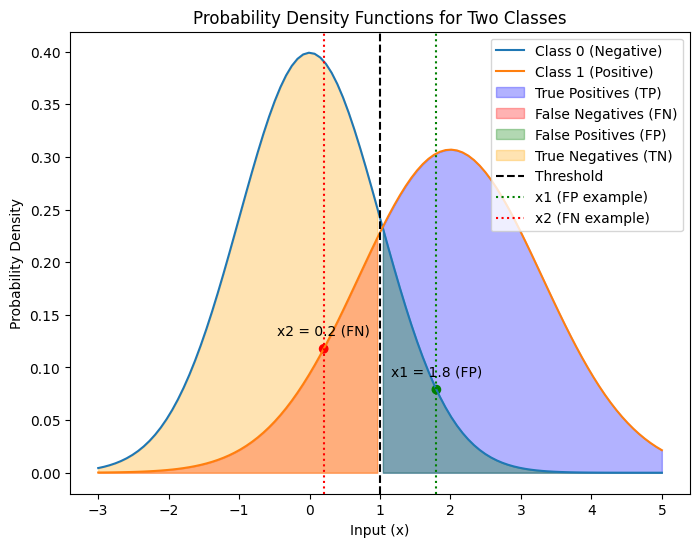

In [18]:
from scipy.stats import norm

# Define the means and standard deviations for the two classes
mean1, std1 = 0, 1
mean2, std2 = 2, 1.3

# Generate x values
x = np.linspace(-3, 5, 100)

# Compute the PDFs for the two classes
pdf1 = norm.pdf(x, mean1, std1)
pdf2 = norm.pdf(x, mean2, std2)

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(x, pdf1, label='Class 0 (Negative)')
plt.plot(x, pdf2, label='Class 1 (Positive)')

# Define a threshold for classification
threshold = 1

# Highlight different regions
plt.fill_between(x, pdf2, where=(x >= threshold), alpha=0.3, color='blue', label='True Positives (TP)')
plt.fill_between(x, pdf2, where=(x < threshold), alpha=0.3, color='red', label='False Negatives (FN)')
plt.fill_between(x, pdf1, where=(x >= threshold), alpha=0.3, color='green', label='False Positives (FP)')
plt.fill_between(x, pdf1, where=(x < threshold), alpha=0.3, color='orange', label='True Negatives (TN)')

# Annotate the plot
plt.axvline(x=threshold, color='black', linestyle='--', label='Threshold')

# Mark example input values
x1 = 1.8  # FP example
x2 = 0.2  # FN example
plt.axvline(x=x1, color='green', linestyle=':', label='x1 (FP example)')
plt.axvline(x=x2, color='red', linestyle=':', label='x2 (FN example)')
plt.scatter([x1, x2], [norm.pdf(x1, mean1, std1), norm.pdf(x2, mean2, std2)], color=['green', 'red'])
plt.annotate(f'x1 = {x1:.1f} (FP)', (x1, norm.pdf(x1, mean1, std1)), textcoords="offset points", xytext=(0,10), ha='center')
plt.annotate(f'x2 = {x2:.1f} (FN)', (x2, norm.pdf(x2, mean2, std2)), textcoords="offset points", xytext=(0,10), ha='center')

plt.xlabel('Input (x)')
plt.ylabel('Probability Density')
plt.title('Probability Density Functions for Two Classes')
plt.legend(loc="upper right")

plt.show()

# Calcifications in Breast Cancer

Calcifications are tiny deposits of calcium in the breast tissue that appear on mammograms as white spots or flecks. They are a common finding and can be benign or occasionally indicative of breast cancer. Understanding their characteristics helps in distinguishing between non-cancerous and suspicious types.

## Types of Calcifications in Breast Imaging

1. **Milk of Calcium**:
   - Appears as sediment-like deposits within breast cysts.
   - Gravity-dependent: changes shape with patient position.
   - Typically benign.

2. **Skin Calcifications**:
   - Located in the skin overlying the breast.
   - Recognized by their distinct patterns.
   - Usually benign and associated with skin conditions.

3. **Dystrophic Calcifications**:
   - Result from tissue damage or necrosis.
   - Usually benign, occurring as part of the body's healing process.
   - Associated with previous injury or inflammation.

4. **Vascular Calcifications**:
   - Occur within blood vessels in the breast.
   - Associated with aging or vascular disease.
   - Typically benign.

5. **Popcorn-Like Calcifications**:
   - Large, coarse, and irregular shapes.
   - Often seen in benign fibroadenomas.
   - Resemble pieces of popcorn in appearance.

6. **Large Rod-Like Calcifications**:
   - Appear as cylindrical shapes.
   - Associated with secretory calcifications.
   - Common in older women and generally benign.

7. **Round Calcifications**:
   - Well-circumscribed, often benign when solitary.
   - Need further evaluation if clustered or in suspicious patterns.

8. **Rim Calcifications**:
   - Ring-like appearance.
   - Associated with oil cysts or fat necrosis.
   - Typically benign in nature.

9. **Amorphous Calcifications**:
   - Indistinct, hazy shapes without a clear form.
   - Considered suspicious and often warrant further evaluation or biopsy to rule out malignancy.

10. **Coarse Heterogeneous Calcifications**:
    - Irregular, larger shapes and often variable in density.
    - Intermediate suspicion; may require closer follow-up or biopsy depending on other imaging findings.

11. **Fine Pleomorphic Calcifications**:
    - Small, varying shapes that are irregular.
    - More suspicious for malignancy, often requiring biopsy for further evaluation.

12. **Fine Linear and Fine Linear Branching Calcifications**:
    - Thin, linear shapes that may branch.
    - Highly suspicious for malignancy, often seen in ductal carcinoma in situ (DCIS).
    - Usually prompt a biopsy to confirm diagnosis.

These descriptors help radiologists assess whether calcifications are benign or require further investigation, with certain patterns being more suggestive of cancerous changes.

# Read the Data & EDA

In [19]:
train = pd.read_csv(r"/kaggle/input/mammography-images/mammography_images/Training_set.csv")


In [20]:
train.head()

,filename,label
0,Image_1.jpg,Density3Benign
1,Image_2.jpg,Density1Benign
2,Image_3.jpg,Density1Malignant
3,Image_4.jpg,Density1Benign
4,Image_5.jpg,Density1Malignant


In [21]:
train.label.value_counts()

label
Density2Malignant    1728
Density1Malignant    1620
Density3Benign        702
Density1Benign        648
Density3Malignant     432
Density4Benign        324
Density2Benign        216
Density4Malignant      54
Name: count, dtype: int64

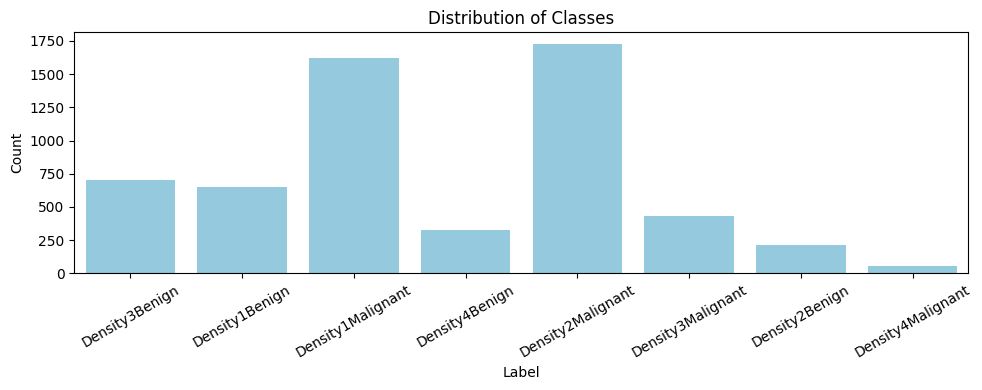

In [22]:
plt.figure(figsize=(10, 4))
sns.countplot(x="label", data=train, color='skyblue')
plt.xticks(rotation=30)
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Distribution of Classes')
plt.tight_layout()

In [23]:
X_train, X_valid = train_test_split(train, test_size=0.1,stratify=train["label"],shuffle=True)

In [24]:
X_valid['label'].value_counts()

label
Density2Malignant    173
Density1Malignant    162
Density3Benign        70
Density1Benign        65
Density3Malignant     43
Density4Benign        33
Density2Benign        22
Density4Malignant      5
Name: count, dtype: int64

## Image Preprocessing Function Explanation

This function enhances the features of an input image using a Laplacian kernel for edge detection or sharpening, followed by normalization to prepare the image for further processing (e.g., for a machine learning model).

**Details:**
- **Laplacian Kernel**: The 3x3 kernel used is a Laplacian filter that highlights edges in the image by emphasizing areas of rapid intensity change.
- **Filter2D**: The kernel is applied to the input image through convolution, enhancing the edges or sharpening the image.
- **Normalization**: The pixel values of the resulting image are scaled to the range [0, 255], ensuring consistency in intensity values for downstream tasks.
- **Output**: The processed and normalized image is returned for further use, such as feeding into a neural network or visualization.

In [25]:
def preprocess(image):
    kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]]) #laplacian 
    im = cv2.filter2D(image, -1, kernel)
    out=(cv2.normalize(im, (224,224),0, 255, cv2.NORM_MINMAX))
    return out

## Data Augmentation and Preprocessing Setup Explanation

This code sets up data generators using `ImageDataGenerator` from Keras to perform data augmentation and preprocessing on image data, specifically tailored for training a machine learning model (e.g., for mammogram analysis).

**Details of the First Generator (`datagen`):**
- **Rescaling**: Pixel values are scaled to the range [0, 1] by multiplying by `1./255`.
- **Preprocessing Function**: A custom preprocessing function (`preprocess`) is applied to each image for additional processing, such as edge enhancement or normalization.

**Details of the Second Generator (`train_datagen`):**
- **Rescaling**: Similar to the first generator, pixel values are scaled to [0, 1].
- **Rotation Range**: Images are randomly rotated within a range of 20 degrees to simulate variations in orientation.
- **Width and Height Shift Range**: Images are randomly shifted horizontally and vertically by up to 20% of their dimensions to account for positional variations.
- **Shear Range**: Applies random shear transformations up to 15% to simulate perspective distortions.
- **Zoom Range**: Randomly zooms into or out of images by up to 15% to mimic different scales.
- **Horizontal Flip**: Randomly flips images horizontally to increase dataset diversity (useful for symmetrical data like mammograms).
- **Vertical Flip**: Disabled, as vertical flipping is typically not appropriate for mammograms due to anatomical constraints.
- **Fill Mode**: Uses the 'nearest' strategy to fill in newly created pixels after transformations.
- **Brightness Range**: Adjusts brightness randomly within 80% to 120% of the original to simulate varying lighting conditions.
- **Preprocessing Function**: Applies the custom `preprocess` function for additional image enhancement or normalization.

**Purpose**: These generators are used to augment the training dataset, making the model more robust to variations in real-world data, while also applying necessary preprocessing steps to ensure the images are in a suitable format for training.

In [26]:
datagen=ImageDataGenerator(rescale=1./255,preprocessing_function=preprocess)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,          # Random rotation within 20 degrees
    width_shift_range=0.2,      # Random horizontal shift
    height_shift_range=0.2,     # Random vertical shift
    shear_range=0.15,           # Shear transformations
    zoom_range=0.15,            # Random zoom
    horizontal_flip=True,       # Random horizontal flips
    vertical_flip=False,        # Typically mammograms shouldn't be flipped vertically
    fill_mode='nearest',        # Fill strategy for created pixels
    brightness_range=[0.8, 1.2],# Brightness variation
    preprocessing_function=preprocess  # Your custom preprocessing function
)



In [27]:
train_generator=train_datagen.flow_from_dataframe(
dataframe=X_train,
directory=r"/kaggle/input/mammography-images/mammography_images/train",
x_col="filename",
y_col="label",
batch_size=32,
seed=42,
shuffle=True,
class_mode="categorical",
target_size=(224,224))

Found 5151 validated image filenames belonging to 8 classes.


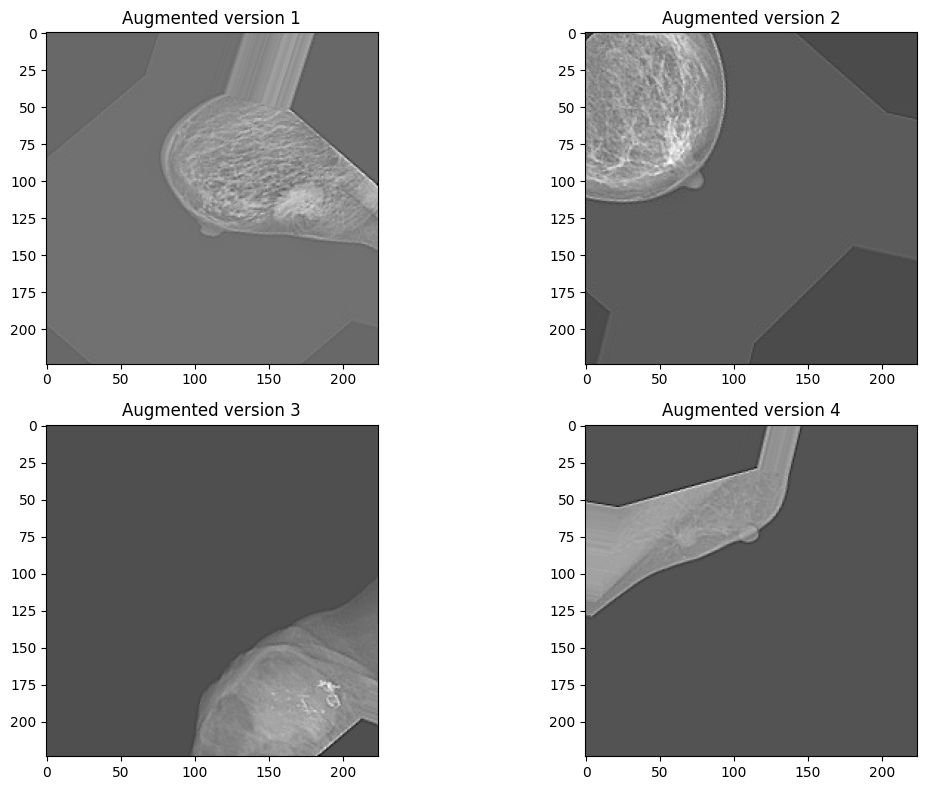

In [28]:
# Display a few augmented images from a single original
import matplotlib.pyplot as plt

# Get a batch from your generator
x_batch, y_batch = next(train_generator)

# Show original and multiple augmented versions
plt.figure(figsize=(12, 8))
for i in range(4):  # Show 4 different augmented versions
    x_batch, y_batch = next(train_generator)
    plt.subplot(2, 2, i+1)
    plt.imshow(x_batch[0])  # Display first image of batch
    plt.title(f"Augmented version {i+1}")
plt.tight_layout()
plt.show()

In [29]:
x_batch.shape

(32, 224, 224, 3)

In [30]:
y_batch.shape

(32, 8)

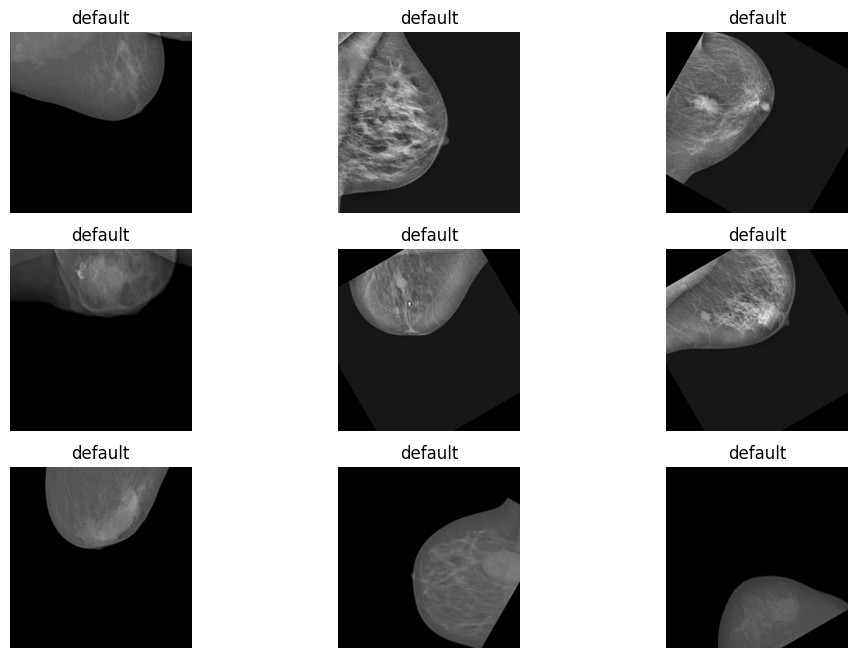

In [31]:
from PIL import Image
plt.figure(figsize=(12, 8))
for i in range(9):
    filename = X_train['filename'].iloc[i]
    img_path = os.path.join(r"/kaggle/input/mammography-images/mammography_images/train", filename)
    img = Image.open(img_path)
    img_array = np.array(img)
    plt.subplot(3, 3, i+1)
    plt.imshow(img_array)
    plt.title(f"default")
    plt.axis('off')

Found 573 validated image filenames belonging to 8 classes.


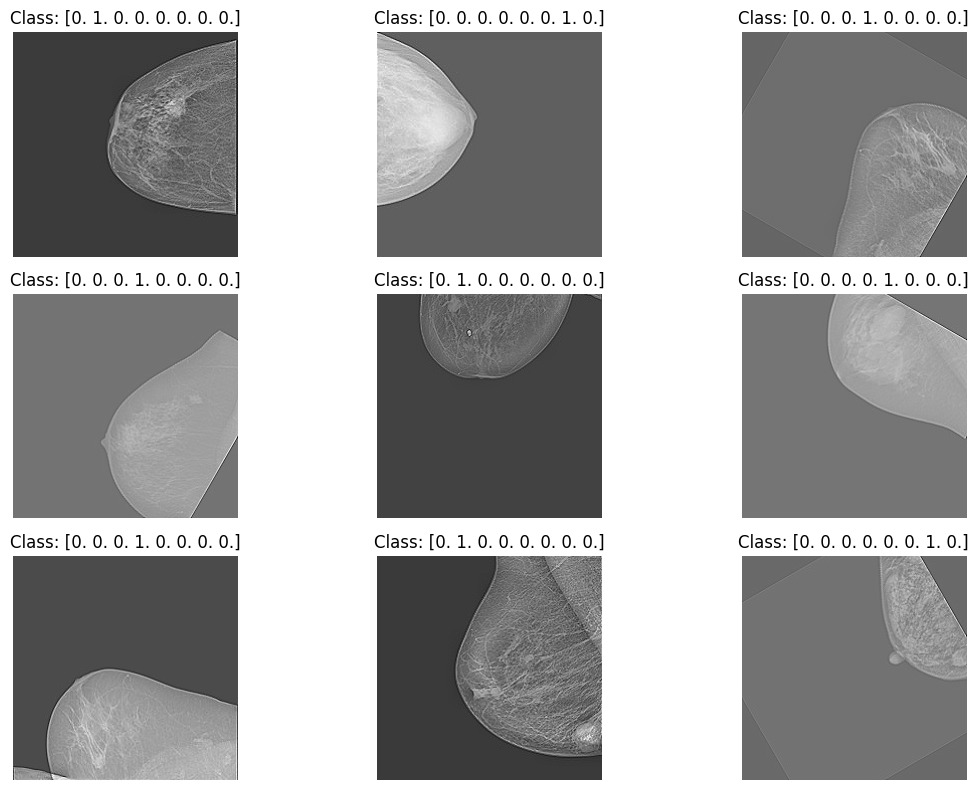

In [32]:
valid_datagen=ImageDataGenerator(rescale=1./255.,preprocessing_function=preprocess)
valid_generator=valid_datagen.flow_from_dataframe( 
dataframe=X_valid,
directory=r"/kaggle/input/mammography-images/mammography_images/train",
x_col="filename",
y_col="label",
batch_size=32,
seed=42,
shuffle=True,
class_mode="categorical",
target_size=(224,224))


x_val, y_val = next(valid_generator)
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_val[i])
    plt.title(f"Class: {y_val[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Modeling

In [33]:
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D, BatchNormalization, Dropout,AveragePooling2D
from tensorflow.keras.applications.resnet import ResNet50
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3,DenseNet201,EfficientNetB7, MobileNetV2,Xception,VGG16,NASNetMobile
from keras.applications.inception_resnet_v2 import InceptionResNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.models import Model
from keras.models import Sequential
from keras.regularizers import *
from tensorflow import keras
from tensorflow.keras import layers

## Model Training Callbacks Setup Explanation

This code sets up essential callbacks for training a deep learning model using TensorFlow/Keras. Callbacks are used to monitor the training process, save model weights, and adjust hyperparameters dynamically to improve performance and prevent overfitting.

**Details of the Code and Callbacks:**

- **Checkpoint Directory Creation**:
  - A directory path for saving model checkpoints is defined as `training_0/cp.weights.h5`. The extension `.weights.h5` is used to indicate that only the weights of the model will be saved.
  - The `os.makedirs` function ensures the directory exists, creating it if necessary, to avoid errors during training.

- **Defined Callbacks**:
  1. **ModelCheckpoint**:
     - Monitors `val_accuracy` to save the model's weights when validation accuracy improves.
     - Saves only the weights (not the full model) with `save_weights_only=True`, which requires the `.weights.h5` extension.
     - Saves only the best model weights based on validation accuracy (`save_best_only=True`) with the mode set to `max` (higher accuracy is better).
     - Provides verbose output to log when weights are saved.

  2. **EarlyStopping**:
     - Monitors `val_accuracy` and stops training if there is no improvement for 5 consecutive epochs (`patience=5`).
     - Restores the best weights observed during training (`restore_best_weights=True`) when stopping.
     - Uses `max` mode since higher validation accuracy is better, and provides verbose output for logging.

  3. **ReduceLROnPlateau**:
     - Monitors `val_loss` and reduces the learning rate by a factor of 0.1 (`factor=0.1`) if there is no improvement in validation loss for 5 epochs (`patience=5`).
     - Uses `min` mode since lower validation loss is better.
     - Applies a minimum improvement threshold (`min_delta=1e-4`) to consider a change significant.
     - Provides verbose output to log when the learning rate is reduced.

**Purpose**: These callbacks help optimize the training process by saving the best model weights, preventing overfitting through early stopping, and dynamically adjusting the learning rate to improve convergence. They ensure efficient training and better model performance on validation data.

In [34]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Create checkpoint directory with the proper extension
checkpoint_path = "training_0/cp.weights.h5"  # Changed extension to .weights.h5
checkpoint_dir = os.path.dirname(checkpoint_path)
os.makedirs(checkpoint_dir, exist_ok=True)

# Define callbacks with corrected filepath
my_callbacks = [
    ModelCheckpoint(
        filepath=checkpoint_path,  # Now has the correct extension
        monitor='val_accuracy',
        verbose=1,
        save_weights_only=True,  # This requires .weights.h5 extension
        save_best_only=True,
        mode="max"
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=10, 
        verbose=1,
        mode='max',
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.1, 
        patience=5, 
        verbose=1, 
        mode='min',
        min_delta=1e-4
    )
]

In [35]:
STEP_SIZE_TRAIN=train_generator.n//train_generator.batch_size
STEP_SIZE_VALID=valid_generator.n//valid_generator.batch_size

## Model Building Function Explanation

This function, `build_model`, constructs a deep learning model for image classification using a pre-trained DenseNet201 as the base architecture, with additional layers for customization. The model is designed for a specific task, such as classifying images into 8 categories.

**Details of the Model Architecture:**

- **Sequential Model**:
  - The model is built using Keras' `Sequential` API, which allows layers to be stacked linearly.

- **Base Model (DenseNet201)**:
  - A pre-trained `DenseNet201` model is used as the convolutional base. It is initialized with:
    - `input_shape=(224, 224, 3)` to accept RGB images of size 224x224 pixels.
    - `include_top=False` to exclude the original fully connected layers, allowing custom layers to be added.
    - `pooling='max'` to apply global max pooling to the output of the convolutional base, reducing spatial dimensions.
    - `weights='imagenet'` to load weights pre-trained on the ImageNet dataset for transfer learning.

- **Custom Layers**:
  1. **BatchNormalization**: Added after the base model to normalize activations, helping to stabilize and accelerate training.
  2. **Dense Layer (2048 units)**: A fully connected layer with 2048 neurons and ReLU activation for non-linearity. It includes L1 and L2 regularization (`kernel_regularizer=l1_l2(0.01)`) to prevent overfitting by penalizing large weights.
  3. **BatchNormalization**: Another normalization layer to further stabilize training.
  4. **Dense Layer (8 units)**: The output layer with 8 neurons (corresponding to 8 classes) and `softmax` activation to produce class probabilities.

- **Fine-Tuning Setup**:
  - The last 5 layers of the DenseNet201 base are selected for fine-tuning (`train_layers`).
  - All other layers in the base model are frozen (`trainable=False`) to retain the pre-trained weights, while the selected layers are set to `trainable=True` to allow fine-tuning for the specific task.

**Purpose**: This model leverages transfer learning by using a pre-trained DenseNet201 for feature extraction, while custom layers are added for classification into 8 categories. Fine-tuning only the top layers of the base model helps adapt it to the specific dataset while preserving the general features learned from ImageNet, balancing efficiency and task-specific performance.

In [36]:
def build_model():
  model = Sequential()

  conv_base = DenseNet201(input_shape=(224,224,3), include_top=False, pooling='max',weights='imagenet')
  model.add(conv_base)
  model.add(BatchNormalization())
  model.add(Dense(2048, activation='relu', kernel_regularizer=l1_l2(0.01)))
  model.add(BatchNormalization())
  model.add(Dense(8, activation='softmax'))

  train_layers = [layer for layer in conv_base.layers[::-1][:5]]

  for layer in conv_base.layers:
    if layer in train_layers:
      layer.trainable = True
  return model

In [37]:
my_model=build_model()

I0000 00:00:1747239447.250914      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1747239447.251537      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [38]:
my_model.compile(optimizer =tf.keras.optimizers.Adam(learning_rate=0.00001,decay=0.0001),metrics=["accuracy"],loss= tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1))

In [39]:
my_model.fit(
        train_generator,
        steps_per_epoch=STEP_SIZE_TRAIN,
        epochs=25,
        validation_data=valid_generator,
        validation_steps=STEP_SIZE_VALID,callbacks=[my_callbacks])

Epoch 1/25


I0000 00:00:1747239604.391662      65 service.cc:148] XLA service 0x78e9680715d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747239604.392352      65 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1747239604.392376      65 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1747239618.944049      65 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1747239861.919006      65 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1490 - loss: 753.6035
Epoch 1: val_accuracy improved from -inf to 0.14890, saving model to training_0/cp.weights.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 790s 2s/step - accuracy: 0.1493 - loss: 753.5185 - val_accuracy: 0.1489 - val_loss: 712.8021 - learning_rate: 1.0000e-05
Epoch 2/25
  1/160 ━━━━━━━━━━━━━━━━━━━━ 1:33 587ms/step - accuracy: 0.2188 - loss: 712.5452
Epoch 2: val_accuracy improved from 0.14890 to 0.17241, saving model to training_0/cp.weights.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 24s 148ms/step - accuracy: 0.2188 - loss: 712.5452 - val_accuracy: 0.1724 - val_loss: 712.4642 - learning_rate: 1.0000e-05
Epoch 3/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.3187 - loss: 698.7880
Epoch 3: val_accuracy improved from 0.17241 to 0.25919, saving model to training_0/cp.weights.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 94s 567ms/step - accuracy: 0.3189 - loss: 698.7061 - val_accuracy: 0.2592 - val_loss: 659.6690 - learning_rate: 1.0000e-05


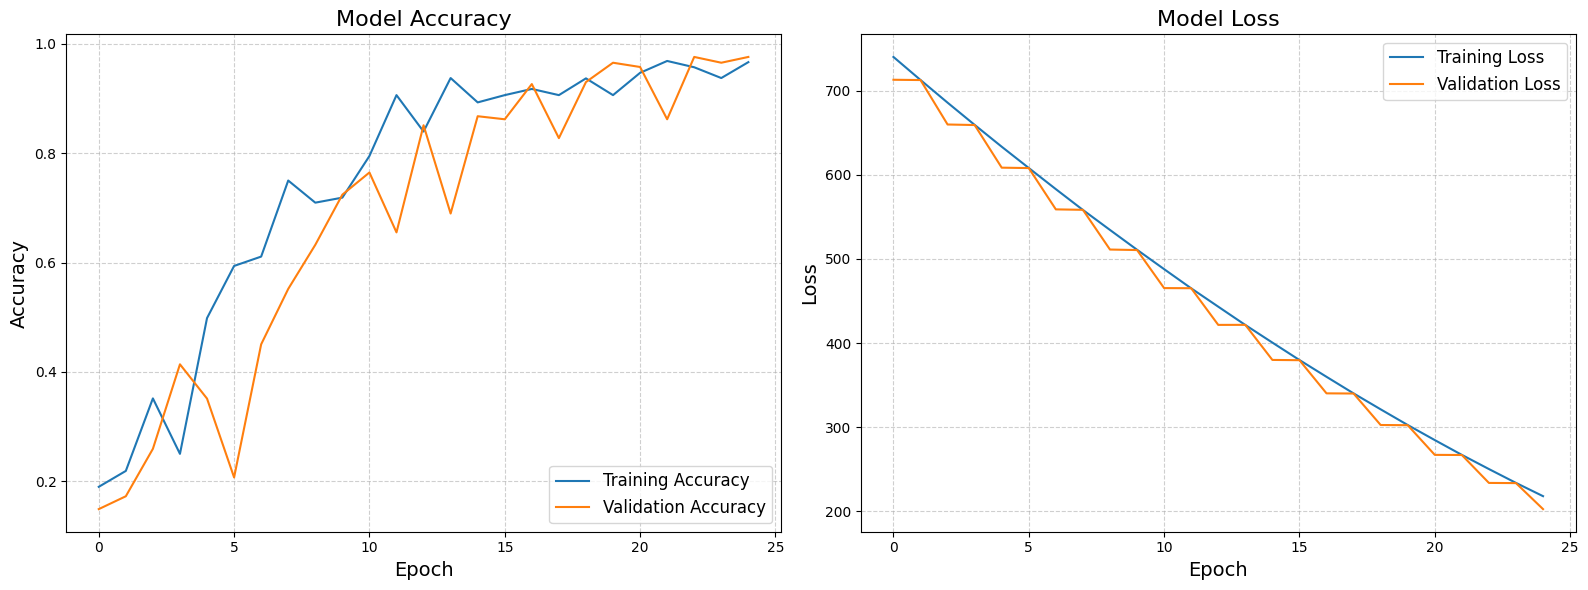

In [40]:
# Try to access history from the model
if hasattr(my_model, 'history') and my_model.history is not None:
    history = my_model.history
    
    # Create a figure with 2 subplots side by side
    plt.figure(figsize=(16, 6))
    
    # Plot training & validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy', fontsize=16)
    plt.ylabel('Accuracy', fontsize=14)
    plt.xlabel('Epoch', fontsize=14)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Plot training & validation loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss', fontsize=16)
    plt.ylabel('Loss', fontsize=14)
    plt.xlabel('Epoch', fontsize=14)
    plt.legend(loc='upper right', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
else:
    print("History not available directly from model.")